#Trabajo Final - Aprendizaje de Máquina I - CEIA 2024 - Coh17
Integrantes:
* Agustina Quiros (agustinaqr@gmail.com)
* Agustín de la Vega (delavega.agus@gmail.com)
* Florentino Arias (florito.arias@gmail.com)

Fecha de entrega: 20/10/2024

### **Sobre los datos**

Para realizar le trabajo se utilizó un dataset que contiene un conjunto de canciones pertenecientes a una playlist de Spotify de un usuario especifico.

La variable objetivo del dataset se denomina `label`, se trata de una **variable binaria** que indica si al usuario le gusta o no la canción.

[Dataset disponible en google drive](https://drive.google.com/file/d/1c1l3OMUFjQWcydV0srKe95LLEfkBMKia/view)

### **Objetivo**
El objetivo es predecir si una nueva canción no escuchada por el usuario será de su preferencia, basado en las características de su playlist actual.


---


### **Secciones del desarrollo propuesto**

**Análisis y Preprocesamiento de datos**
*   Análisis descriptivo
*   Correlaciones entre características
*   Detección de outliers
*   Limpieza del dataset
*   Técnicas de visualización de variables


**Selección y transformación de variables**
* Transformación de variables
* Ténicas de Reducción de dimensionalidad

**Entrenamiento de Modelos**

* Logistic Regression
* Decision Tree
* K-Neighbors Classifier

Modelos Ensemble
* LightGBM
* XGBoost
* Random Forest

**Comparación de métricas de modelos**
* Accuracy
* Precision
* Recall
* F1-Score

**Conclusiones**


## Análisis de datos

Importamos las librerías necesarias:

In [ ]:
# Obtener datos
from google.colab import drive
import requests

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


### Adquirir datos

El set de datos elegido es una lista de temas de **Spotify** (data_playlist.csv). En primer lugar, cargamos el dataset y realizamos un análisis exploratorio de los datos con sample() para tener una idea de la estructura y características del mismo. También podríamos utilizar head() o tail() si vemos que es necesario ver más ejemplos.

In [ ]:
with requests.get(
    "https://drive.google.com/uc?export=download&id=1c1l3OMUFjQWcydV0srKe95LLEfkBMKia"
) as r, open("data_playlist.csv", "wb") as f:
    for chunk in r.iter_content():
        f.write(chunk)

df = pd.read_csv("data_playlist.csv")

In [ ]:
df.sample(5)

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
433,0.144,0.904,111304,0.555,0.008640,5,0.115,-5.157,1,0.0820,138.084,1,0.502,0
631,0.938,0.407,387827,0.356,0.882000,8,0.147,-16.535,1,0.0406,82.209,4,0.311,1
44,0.271,0.769,272333,0.396,0.038600,10,0.184,-15.419,1,0.0302,105.845,4,0.622,1
672,0.441,0.737,111422,0.516,0.000035,2,0.122,-8.023,1,0.0411,117.027,4,0.532,1
616,0.267,0.703,220280,0.911,0.056000,5,0.170,-6.015,1,0.0275,127.974,4,0.949,1


### Features disponibles en el set de datos

In [ ]:
df.columns.values

array(['acousticness', 'danceability', 'duration', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence', 'label'],
      dtype=object)

En esta [página](https://developer.spotify.com/documentation/web-api/reference/get-audio-features)  podemos encontrar información detallada de las features de este dataset.

0. **acousticness** (float64)

Descripción: Medida de cuán acústica es una pista.
Rango de valores: 0.0 a 1.0.
Interpretación: Un valor cercano a 1.0 indica una alta probabilidad de que la pista sea acústica, es decir, que utiliza instrumentos acústicos y tiene poca o ninguna producción electrónica.

1. **danceability** (float64)

Descripción: Indica qué tan bailable es una pista.
Rango de valores: 0.0 a 1.0.
Interpretación: Valores más altos significan que la pista es más adecuada para bailar, teniendo en cuenta elementos como el tempo, la estabilidad del ritmo y la regularidad.

2. **duration** (int64)

Descripción: Duración total de la pista.
Unidad de medida: Milisegundos.
Interpretación: Indica la longitud de la canción.

3. **energy** (float64)

Descripción: Medida de intensidad y actividad percibida en una pista.
Rango de valores: 0.0 a 1.0.
Interpretación: Pistas con valores altos suelen ser más ruidosas y rápidas, transmitiendo una sensación de energía y entusiasmo.

4. **instrumentalness** (float64)

Descripción: Predice si una pista no contiene voces.
Rango de valores: 0.0 a 1.0.
Interpretación: Valores cercanos a 1.0 indican una mayor probabilidad de que la pista sea instrumental. Valores por encima de 0.5 sugieren que la pista probablemente no tiene contenido vocal.

5. **key** (int64)

Descripción: Tono musical en el que está compuesta la pista.
Valores posibles: Enteros de 0 a 11, donde cada número corresponde a una nota:
0 = Do 1 = Do♯/Re♭ 2 = Re 3 = Re♯/Mi♭ 4 = Mi 5 = Fa 6 = Fa♯/Sol♭ 7 = Sol 8 = Sol♯/La♭ 9 = La 10 = La♯/Si♭ 11 = Si

6. **liveness** (float64)

Descripción: Detecta la presencia de una audiencia en la grabación.
Rango de valores: 0.0 a 1.0.
Interpretación: Valores por encima de 0.8 indican una alta probabilidad de que la pista haya sido grabada en vivo.

7. **loudness** (float64)

Descripción: Volumen general de una pista.
Unidad de medida: Decibelios (dB).
Interpretación: Valores más bajos indican pistas más silenciosas. Es una medida promedio de la intensidad sonora.

8. **mode** (int64)

Descripción: Indica el modo de la escala musical de la pista.
Valores posibles: 0 = Menor - 1 = Mayor.

Interpretación: El modo menor suele asociarse con emociones más tristes o serias, mientras que el modo mayor se asocia con emociones más felices o alegres.

9. **speechiness** (float64)

Descripción: Detecta la presencia de palabras habladas en una pista.
Rango de valores: 0.0 a 1.0.
Interpretación:
Valores cercanos a 0.0 indican poca o ninguna presencia de habla.
Valores entre 0.33 y 0.66 pueden representar pistas que contienen tanto música como habla (por ejemplo, rap).
Valores por encima de 0.66 indican que la pista es predominantemente hablada (como un audiolibro).

10. **tempo** (float64)

Descripción: Velocidad o ritmo general de la pista.
Unidad de medida: Pulsaciones por minuto (BPM).
Interpretación: Indica la velocidad con la que se toca una canción. Valores más altos significan un tempo más rápido.

11. **time_signature** (int64)

Descripción: Compás de la pista.
Valores posibles: Números enteros (habitualmente entre 3 y 7).
Interpretación: Indica el número de tiempos por compás. Por ejemplo, un valor de 4 significa que hay cuatro tiempos en cada compás.

12. **valence** (float64)

Descripción: Medida de la positividad musical transmitida por una pista.
Rango de valores: 0.0 a 1.0.
Interpretación: Valores altos indican pistas más positivas (alegres, eufóricas), mientras que valores bajos indican pistas más negativas (tristes, enojadas).

13. **label** (int64)

Descripción: Etiqueta que indica si la pista le gusta o no al usuario. 0 = No - 1 = Sí

Obtenemos las características principales del dataset utilizando info():

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
 13  label             750 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 82.2 KB


Nos interesa: número de observaciones, número de variables y tipos de datos.
De la salida del comando info() podemos ver que hay 750 observaciones (filas) y 14 variables o features (columnas). A continuación detallamos los nombres de las columnas y sus tipos de datos:

acousticness,  danceability, energy, instrumentalness, liveness, loudness, speechiness, tempo, valence: **float64**;

key, duration, mode, time_signature, label: **int64**.

**No hay valores nulos** en ninguna fila en ningún feature (todos dicen 750 non-null). Todas las variables son **cuantitativas**: 4 discretas y el resto continuas.

**Clasificación de variables**

**Discretas**: solo pueden tomar un número finito de valores, típicamente números enteros.

* key (int64): Puede tomar valores enteros entre 0 y 11, donde cada valor representa una nota musical específica.
* duration (int64): Medida en milisegundos.
* mode (int64): Solo puede tomar dos valores, 0 (menor) y 1 (mayor), indicando el modo musical.
* time_signature (int64): Toma valores enteros que representan el número de tiempos por compás, típicamente entre 3 y 7.
* label (int64): Es una variable categórica binaria (0 = No, 1 = Sí).

**Continuas**: pueden tomar cualquier valor dentro de un rango, típicamente números reales.

* acousticness (float64): Es una medida que va de 0.0 a 1.0.
* danceability (float64): Varía entre 0.0 y 1.0, midiendo la bailabilidad de una pista.
* energy (float64): Varía entre 0.0 y 1.0.
* instrumentalness (float64): Toma valores entre 0.0 y 1.0.
* liveness (float64): Varía entre 0.0 y 1.0.
* loudness (float64): Es una medida en decibelios que puede tomar cualquier valor dentro de un rango amplio.
* speechiness (float64): Toma valores entre 0.0 y 1.0.
* tempo (float64): Representa el ritmo de la pista en BPM.
* valence (float64): Varía entre 0.0 y 1.0.



Dada esta descripción de las características del dataset, nuestra variable objetivo será **label**, es decir que nos interesa saber, dada una lista de características de una canción, si la misma será de gusto del usuario o no.

A lo largo del presente análisis vamos a determinar cómo se distribuyen los valores de las variables, sus particularidades, transformaciones necesarias y veremos cuáles son las que más influyen en el valor de la variable destino.

### Análisis de variables

In [ ]:
# Estadísticas descriptivas
df.describe()

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,0.357394,0.596439,220112.733333,0.594188,0.100245,4.829333,0.203376,-8.509339,0.741333,0.098966,120.405761,3.902667,0.497321,0.602667
std,0.338405,0.172036,65587.690483,0.253301,0.259921,3.636001,0.177609,5.039488,0.438194,0.104715,28.378116,0.400091,0.239615,0.489673
min,0.000001,0.107000,33840.000000,0.009250,0.000000,0.000000,0.024000,-29.601000,0.000000,0.023400,55.747000,1.000000,0.033200,0.000000
25%,0.037150,0.480000,185490.250000,0.423250,0.000000,1.000000,0.094550,-10.173500,0.000000,0.035900,98.998000,4.000000,0.297000,0.000000
50%,0.244500,0.606000,215108.500000,0.631500,0.000010,5.000000,0.129000,-7.270000,1.000000,0.048750,120.104500,4.000000,0.483000,1.000000
75%,0.678500,0.715750,244236.750000,0.804750,0.002245,8.000000,0.264750,-5.097750,1.000000,0.113000,138.074750,4.000000,0.684500,1.000000
max,0.994000,0.986000,675360.000000,0.995000,0.967000,11.000000,0.979000,-0.533000,1.000000,0.721000,204.162000,5.000000,0.975000,1.000000


- acousticness:
  - std: 0.338 indica una amplia variación en el nivel de acústica entre las canciones.
  - cuartiles: el 50% de las canciones tienen valores de acústica menores a 0.2445, lo que indica que hay muchas canciones con poca acústica.
- danceability:
  - mean: 0.60, lo que indica que la mayoría de las pistas son moderadamente bailable.
  - cuartiles: el 50% de las canciones tienen un nivel de bailabilidad de al menos 0.606, lo que indica que son razonablemente bailables. El 25% de las canciones más bailables tienen un índice de bailabilidad superior a 0.715.
- duration:
  - mean: 220,112 ms (~3 minutos y 40 segundos), una duración típica para canciones comerciales.
  - cuartiles: la mayoría de las canciones duran entre 3 y 4 minutos. El 25% superior tiene una duración superior a 4 minutos, mientras que el 25% más corto tiene una duración inferior a 3.09 minutos.
- energy:
  - mean: 0.59, lo que implica que la mayoría de las pistas tienen un nivel moderado de energía.
  - cuartiles: la energía está muy distribuida, el 25% inferior tiene una energía baja (menos de 0.423), mientras que el 25% superior tiene canciones con mucha energía (más de 0.805).
- instrumentalness:
  - mean: 0.10, lo que significa que la mayoría de las pistas tienen poco contenido instrumental puro.
  - cuartiles: la mayoría de las canciones tienen muy poca instrumentalidad, ya que el 50% de las canciones tienen un valor de instrumentalidad cercano a 0. Solo el 25% superior tiene algo de contenido instrumental significativo.
- key:
  - mean: 4.83 (cercano a Mi), con una dispersión relativamente amplia dado que el tono es una escala circular de 12 tonos.
  - cuartiles: las claves musicales están bastante distribuidas entre todas las tonalidades.
- liveness:
  - mean: 0.20, lo que indica que pocas pistas fueron grabadas en un ambiente en vivo.
  - cuartiles: la mayoría de las canciones no parecen estar grabadas en vivo. El 50% de las canciones tienen una vivacidad por debajo de 0.129, y solo el 25% superior tiene una vivacidad significativamente alta.
- loudness:
  - mean: -8.51 dB, indicando un volumen promedio típico para música, donde -8 dB suele ser bastante alto en la escala de sonoridad.
  - cuartiles: el 75% de las canciones tienen un volumen más bajo que -5.1 dB, lo que indica que la mayoría de las canciones no están masterizadas para ser extremadamente fuertes. Solo el 25% más ruidoso tiene un volumen por encima de este umbral.
- mode:
  - mean: 0.74, lo que sugiere que la mayoría de las pistas están en modo mayor (positivo).
  - cuartiles: el 50% de las canciones están en modo mayor, mientras que el 25% inferior están en modo menor.
- speechiness:
  - mean: 0.10, lo que indica que la mayoría de las pistas tienen un contenido hablado bajo o nulo.
  - cuartiles: la mayoría de las canciones tienen un bajo nivel de habla. Solo el 25% superior tiene un nivel de habla por encima de 0.113.
- tempo:
  - mean: 120.41 BPM, lo cual es típico en géneros pop y dance.
  - cuartiles: la mediana de 120 BPM es un tempo muy común en muchas canciones populares.
- time_signature:
  - mean: 3.9 (~4/4), lo cual es el compás más común en la música popular.
- valence:
  - mean: 0.50, sugiriendo que el conjunto tiene un balance entre canciones alegres y tristes.
  - cuartiles: el 50% de las canciones tienen una valencia de 0.483 o menos, lo que indica que tienden a ser emocionalmente neutras o ligeramente negativas. El 25% superior tiene una valencia mayor a 0.685, lo que sugiere canciones más positivas o alegres.

### Valores Nulos


In [ ]:
df.isnull().sum().to_frame('Cantidad')

,Cantidad
acousticness,0
danceability,0
duration,0
energy,0
instrumentalness,0
key,0
liveness,0
loudness,0
mode,0
speechiness,0


### Correlaciones lineales entre "label" y las otras features

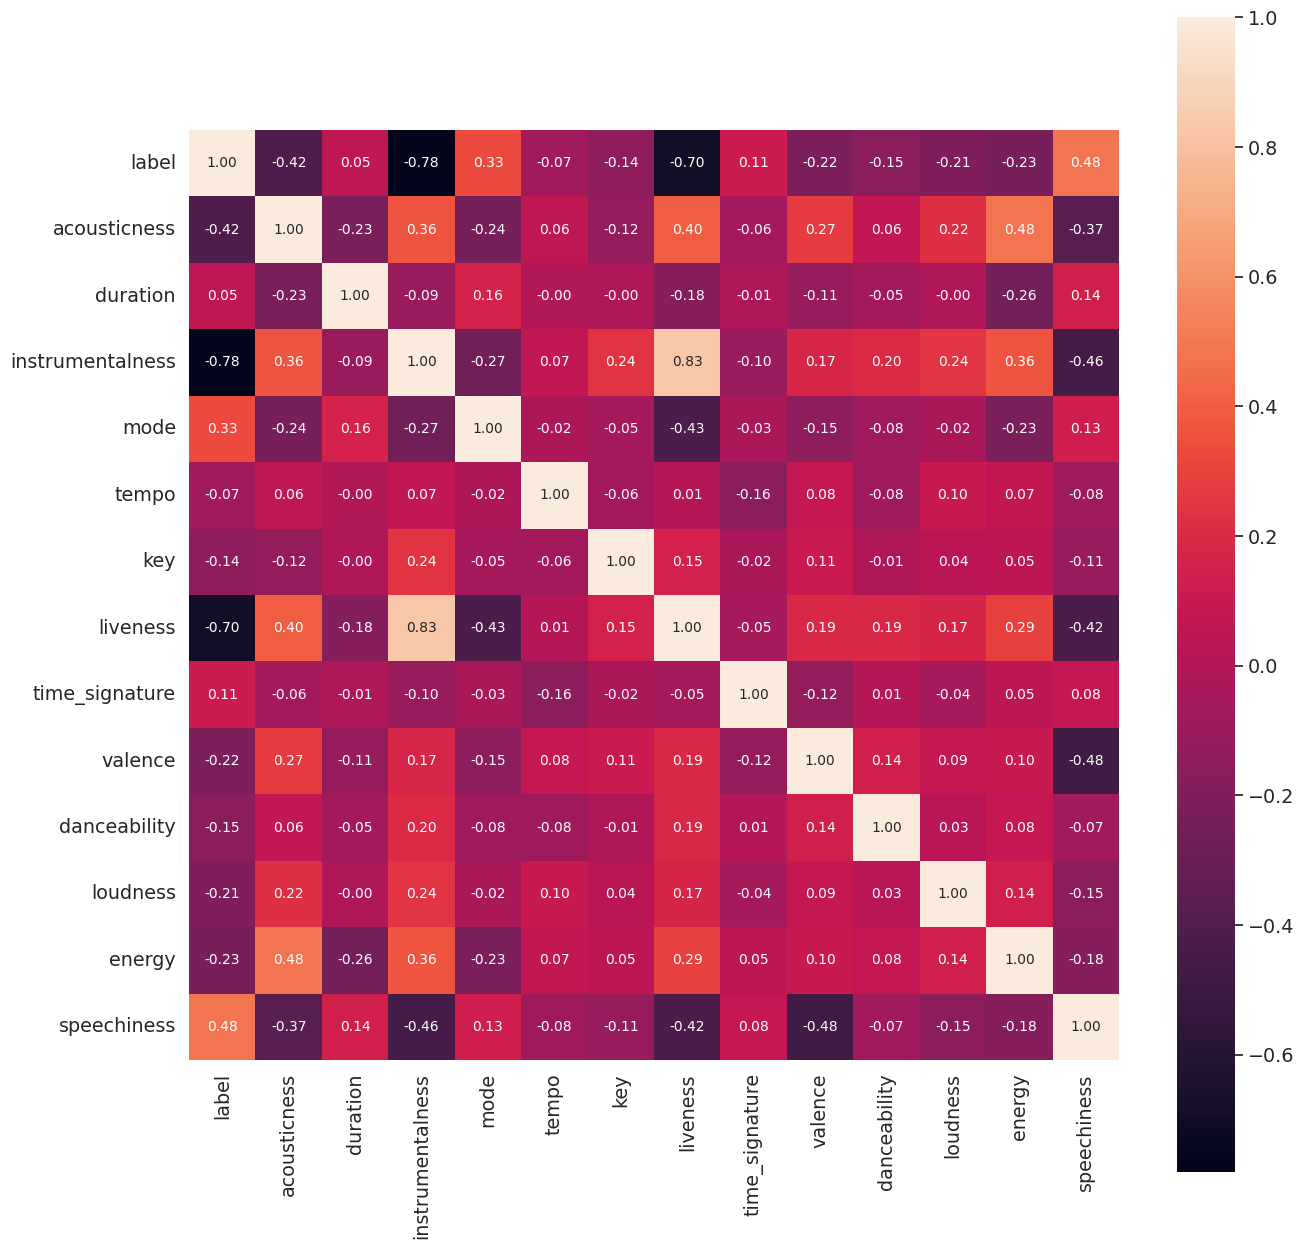

In [ ]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
k = 18
cols = corr.nlargest(k, 'label')['label'].index
sns.set(font_scale=1.25)
fig, ax = plt.subplots(figsize=(15,15))
hm = sns.heatmap(corr, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

plt.show()

* **instrumentalness (-0.78)**: existe una correlación negativa alta entre la probabilidad de que una pista sea instrumental y el gusto del usuario (label). Esto sugiere que al usuario no le gustan tanto las pistas muy instrumentales.
* **liveness (-0.70)**: hay una correlación negativa alta entre la probabilidad de que una pista haya sido grabada en vivo y si es del gusto del usuario. Esto indica que el usuario no prefiere pistas grabadas en vivo.
* **speechiness (0.48)**: la correlación positiva más fuerte con "label". Esto sugiere que las pistas con mayor contenido hablado son del agrado del usuario.
* **acousticness (-0.42)**: existe una correlación negativa moderada entre la probabilidad de que una pista sea acústica y el gusto del usuario (label). Esto sugiere que al usuario tienden a no gustarle tanto las pistas muy acústicas.
* **mode (0.33)**: la correlación positiva moderada indica que el usuario podría preferir pistas en modo mayor, que generalmente se asocian con emociones más felices o alegres.
* **energy (-0.23)**: hay una correlación negativa moderada con la energía. Pistas con mayor energía suelen no gustarle tanto al usuario.
* **valence (-0.22)**: la correlación con "label" es negativa, pero baja. Esto sugiere que la positividad emocional de una pista no influye fuertemente en las preferencias del usuario, aunque parece inclinarse más por pistas menos positivas.
* **loudness (-0.21)**: una correlación negativa leve entre el volumen general de la pista y las preferencias del usuario. Las pistas más ruidosas tienden a ser un poco menos apreciadas.
* **danceability (-0.15)**: la capacidad de baile tiene una correlación negativa baja con "label", lo que indica que el usuario podría no preferir pistas que sean más bailables.
* **key (-0.14), tempo (-0.07), time_signature (0.11), y duration (0.05)**: estas variables tienen correlaciones muy bajas con "label", lo que sugiere que el tono, el tempo, el compás de la pista y su duración sea no son factores determinantes para el gusto del usuario.

### Análisis de like (label) por feature continua

Se proceden a realizar las siguientes gráficas para las features continuas:
- Función de densidad
- KDE

En las gráficas se visualizan las comparaciones entre las canciones "likeadas" (label = 1) y las no "likeadas" (label = 0)

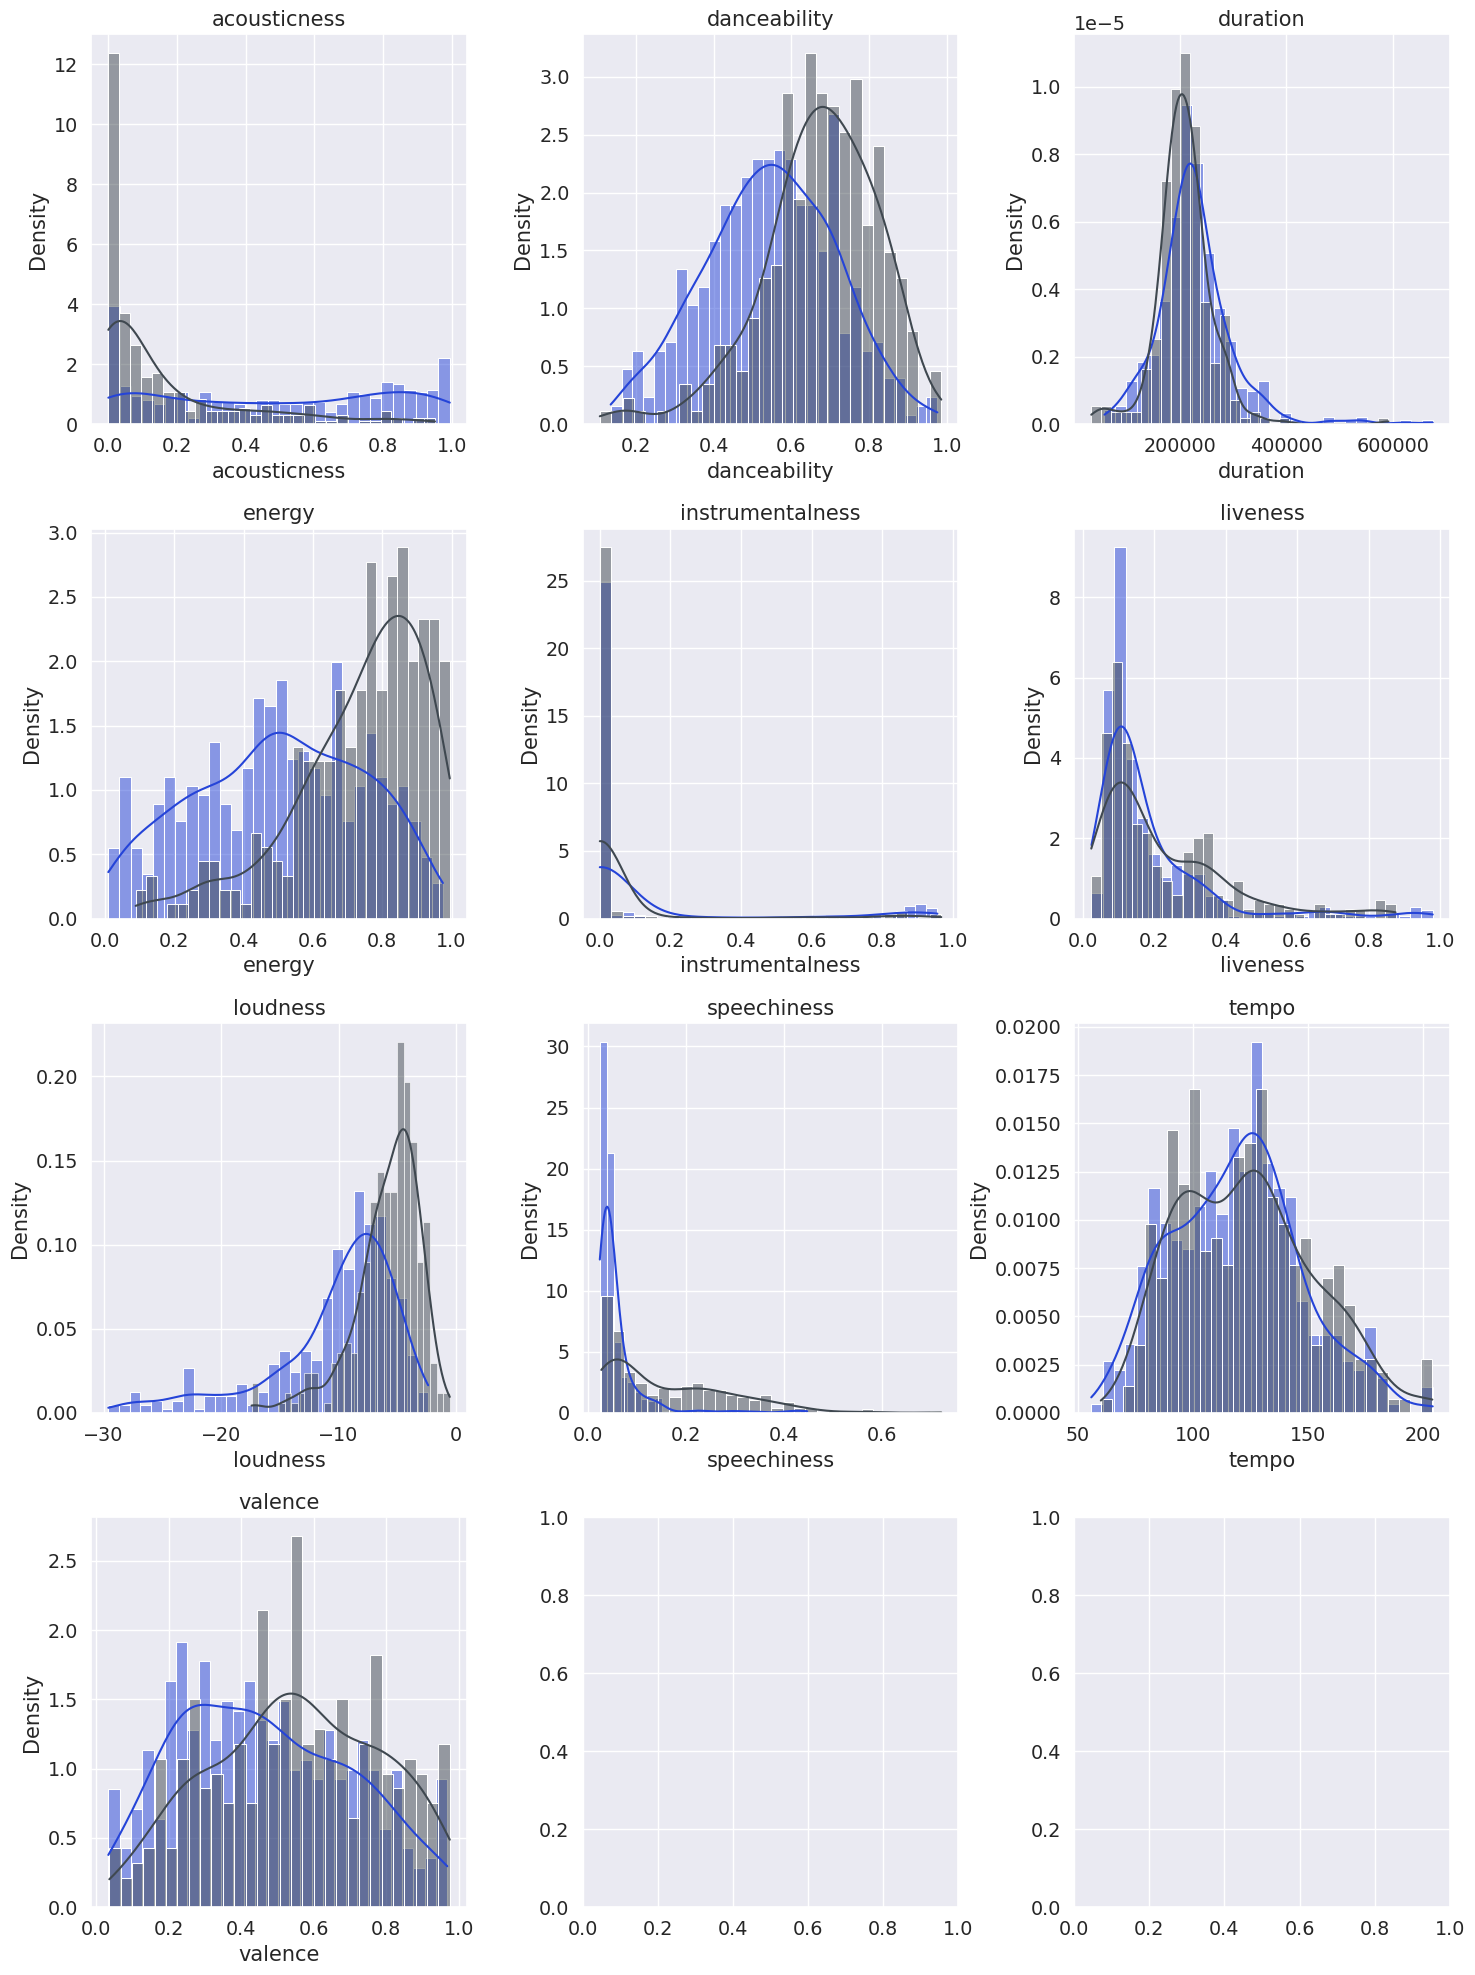

In [ ]:
numerical_features = ['acousticness', 'danceability', 'duration', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

num_cols = 3
num_rows = (len(numerical_features) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

for i, feature in enumerate(numerical_features):
  row = i // num_cols
  col = i % num_cols
  sns.histplot(df[df['label'] == 1][feature], color='#2544d8', label='Liked Songs', kde=True, stat="density", bins=30, ax=axes[row, col])
  sns.histplot(df[df['label'] == 0][feature], color='#3f4850', label='Disliked Songs', kde=True, stat="density", bins=30, ax=axes[row, col])

  axes[row, col].set_title(feature)

plt.tight_layout()
plt.show()

Observaciones

**Acousticness**: Se observa que es mayor la probabilidad que una canción con un valor bajo de acousticness no sea "likeada". Para valores medios de acustica, se "likea" y "dislikea" en mismas proporciones. Para valores elevados de acoustincess, es mayor la probabilidad que guste la canción al usuario.

**Danceability**: Tanto las anciones "likeadas" como no "likeadas" cuentan con distribuciones similares de "bailabilidad". Sin embargo, la media para las canciones no "likeadas" es mayor, por lo que indicaria que canciones con una menor bailabildiad serian más gustadas.

**Duration**: No parece haber diferencias sustanciales entre canciones que le gustan y no le gustan al usuario en terminos de duración de la canción. Ambas duraciones tienen una media y desvio similares.

**Energy**: Hay una gran diferencia entre las distribuciones de canciones "likeadas" y no "likeadas" para la variable de energia. Se observa a través de las gráficas que las canciones con menor energia son mas propensas a ser gustadas y las canciones con un nivel elevado no son preferidas. Para niveles intermedios ~0.5, se gusta y no en probabilidades iguales.

**Instrumentalness**: No se observa mucho en la gráfica, la mayor parte de canciones del set de datos cuentan con una instrumentalidad alta y se "likean" o "dislikean" en proporciones iguales. Sobre el final del rango de la variable se observa un **pequeño** conjunto de canciones con instrumentalidad muy alta, las cuales son gustadas por el usuario

**Liveness**: La gráfica presenta una pequeña diferencia para valores bajos y medios de liveness. Para valores bajos, el usuario "likea" una cancion con mayor probabilidad. Esto indicaría que el usuario tiene una leve preferencia por canciones que no fueron grabadas en vivo. Para valores medios/bajos ~0.35, el usuario da mayor cantidad de "dislike" a canciones. Esto podría indicar que hay alguna pequeña componente del público.

**Loudness**: Gráfica para canciones no gustadas esta desplazada hacia valores mas altos de volúmen, indica que al usuario le suelen gustar canciones con intensidad sonora más baja.

**Speechiness**: El usuario parece preferir canciones sin letra. Practicamente no se observan "likes" para canciones con speechiness > 0.2.

**Tempo**: Ambas gráficas son similares. Pequeña diferencia en la proporcion de canciones "likeadas" y no "likedas" para valores de tempo alrededor de 90 BPM y 160 BPM.

**Valence**: El usuario preferir canciones con un valence más bajo, indicando canciones menos alegres. Se ven dos picos altos de canciones "dislikeadas" para valores medios.

**Duration** e **Instrumentalness** cuentan con distribuciones muy similares, se procede a realizar un diagrama de violin plot para analizar sus distribuciones, medianas y cuartiles

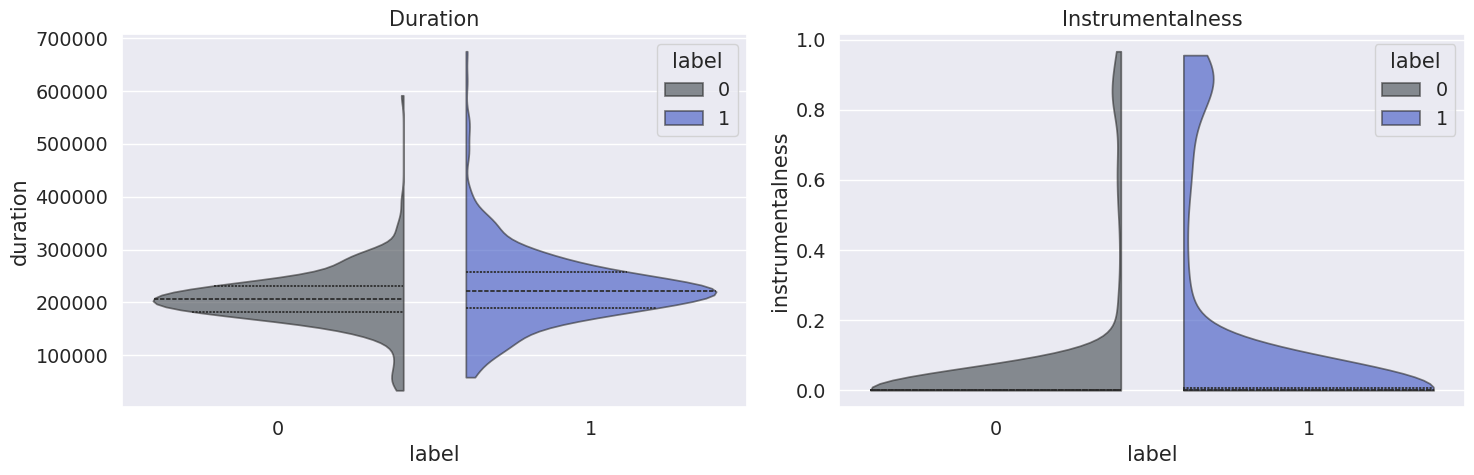

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(x='label', y='duration', data=df, split=True, cut=0, hue='label', inner="quart", palette={0: "#3f4850", 1: "#2544d8"}, alpha=0.6, ax=axes[0])
axes[0].set_title('Duration')

sns.violinplot(x='label', y='instrumentalness', data=df, split=True, cut=0, hue='label', inner="quart", palette={0: "#3f4850", 1: "#2544d8"}, alpha=0.6, ax=axes[1])
axes[1].set_title('Instrumentalness')

plt.tight_layout()
plt.show()

Para la **duración**, se observa que la distribución de canciones "likeadas" esta muy levemente corrida hacia valores mas altos de duración. Las medianas y Q1 son a su vez muy similares. El tercer cuartil es levemente superior para las canciones gustadas por el usuario. No son diferencias significativas, **no pensamos que la feature de duración sea relevante para conocer si una canción es preferida por el usuario**

Para la **instrumentalidad**, se observan dos distribuciones pracicamente iguales. Las medianas y cuartiles son identicas. Se ve una leve diferencia en canciones gustadas para valores extremos de instrumentalidad. No son diferencias significativas, **no pensamos que la feature de instrumentalidad sea relevante para conocer si una canción es preferida por el usuario**

#### Features con mayor impacto
*   Acousticness
*   Energy
*   Danceability
*   Liveness
*   Speechiness
*   Loudness


#### Features con impacto medio
*   Tempo
*   Valence

#### Features sin impacto
*   Instrumentalness
*   Duración


### Analisis de like por variable categorica

Se procede a graficar las distribuciones de probabilidad para las features categoricas comparando las canciones "likeadas" (label = 1) vs no "likeadas" (label = 0)

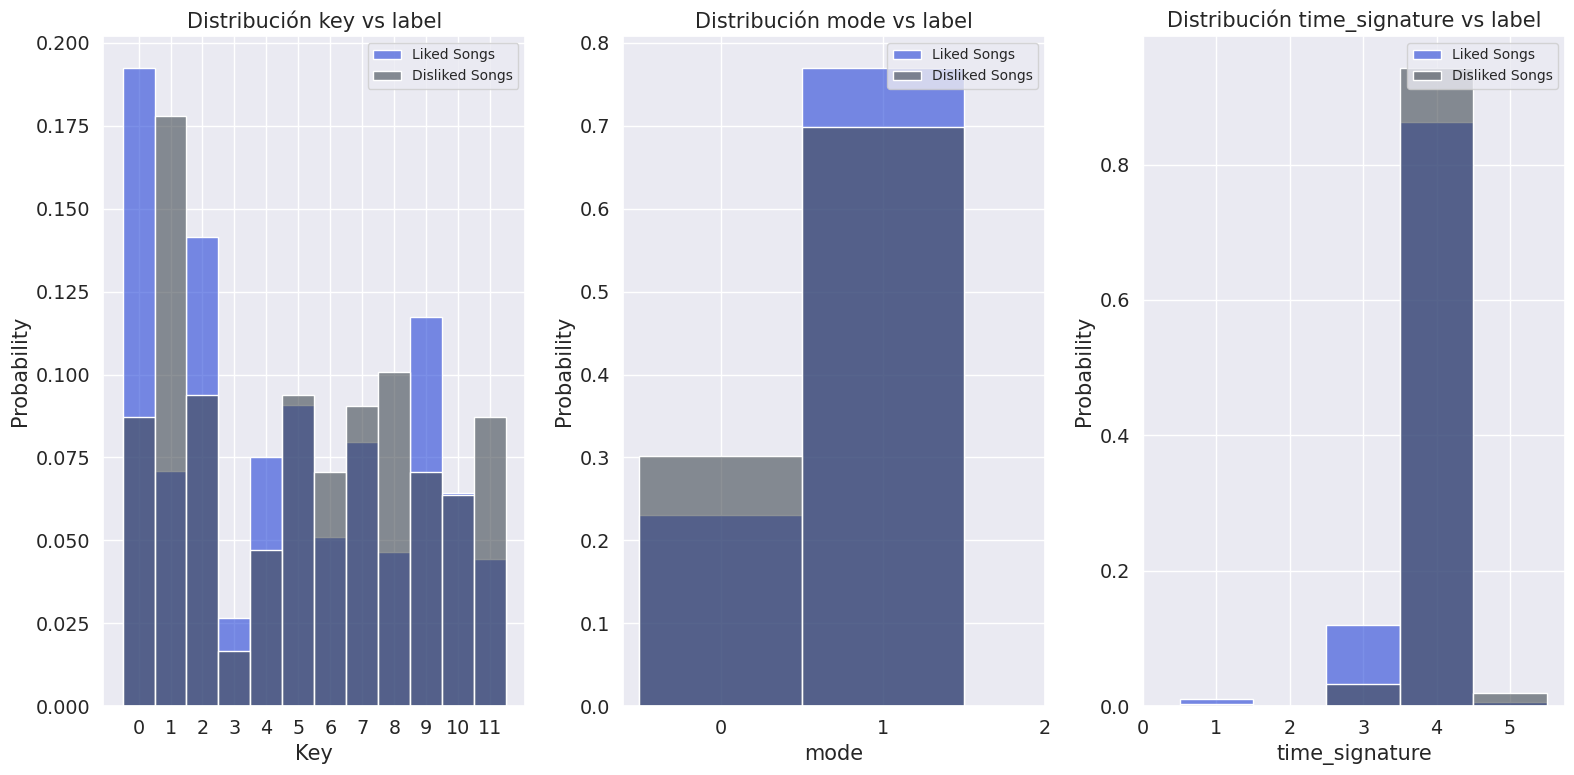

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
sns.histplot(df[df['label'] == 1]['key'], color='#2544d8', label='Liked Songs', stat="probability", bins=range(12), discrete=True, alpha=0.6)
sns.histplot(df[df['label'] == 0]['key'], color='#3f4850', label='Disliked Songs', stat="probability", bins=range(12), discrete=True, alpha=0.6)

plt.title('Distribución key vs label', fontsize=15)
plt.xlabel('Key')
plt.ylabel('Probability')

plt.xticks(range(12))
plt.legend(loc='upper right', fontsize=10)


# Mode vs Label
plt.subplot(1, 3, 2)
sns.histplot(df[df['label'] == 1]['mode'], color='#2544d8', label='Liked Songs', stat="probability", bins=range(3), discrete=True, alpha=0.6)
sns.histplot(df[df['label'] == 0]['mode'], color='#3f4850', label='Disliked Songs', stat="probability", bins=range(3), discrete=True, alpha=0.6)

plt.title('Distribución mode vs label', fontsize=15)
plt.xlabel('mode')
plt.ylabel('Probability')

plt.xticks(range(3))
plt.legend(loc='upper right', fontsize=10)

# Time Signature vs Label
plt.subplot(1, 3, 3)
sns.histplot(df[df['label'] == 1]['time_signature'], color='#2544d8', label='Liked Songs', stat="probability", bins=range(6), discrete=True, alpha=0.6)
sns.histplot(df[df['label'] == 0]['time_signature'], color='#3f4850', label='Disliked Songs', stat="probability", bins=range(6), discrete=True, alpha=0.6)

plt.title('Distribución time_signature vs label', fontsize=15)
plt.xlabel('time_signature')
plt.ylabel('Probability')

plt.xticks(range(6))
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

**Key**: Cuenta con diferencias significativas. La probabilidad que una canción en Do (0), Re (2), Mi (4) o La (9) sea gustada es mayor a que no sea gustada. Lo contrario se daria para las notas Do♯/Re (1), Sol♯/La (8) y  Si (11)

**Mode**:No tiene impacto significativo en la probabilidad que una canción sea "likeada" o no.

**Time Signature**: No tiene impacto significativo en la probabilidad que una canción sea "likeada" o no.

### Limpieza de Dataset

#### Eliminamos datos irrelevantes

Variables que parecen condicionar el like:
*   Acousticness
*   Energy
*   Liveness
*   Speechiness
*   Tempo
*   Valence
*   Danceability
*   Loudness
*   Key

Basándonos en nuestras suposiciones y decisiones, queremos eliminar los features de:
*   Instrumentalness
*   Duration
*   Mode
*   Time Signature


In [ ]:
df.drop(columns=['instrumentalness', 'duration', 'mode', 'time_signature'], inplace=True)

#### Outliers

##### Método del desvío estándar ó Z-Score

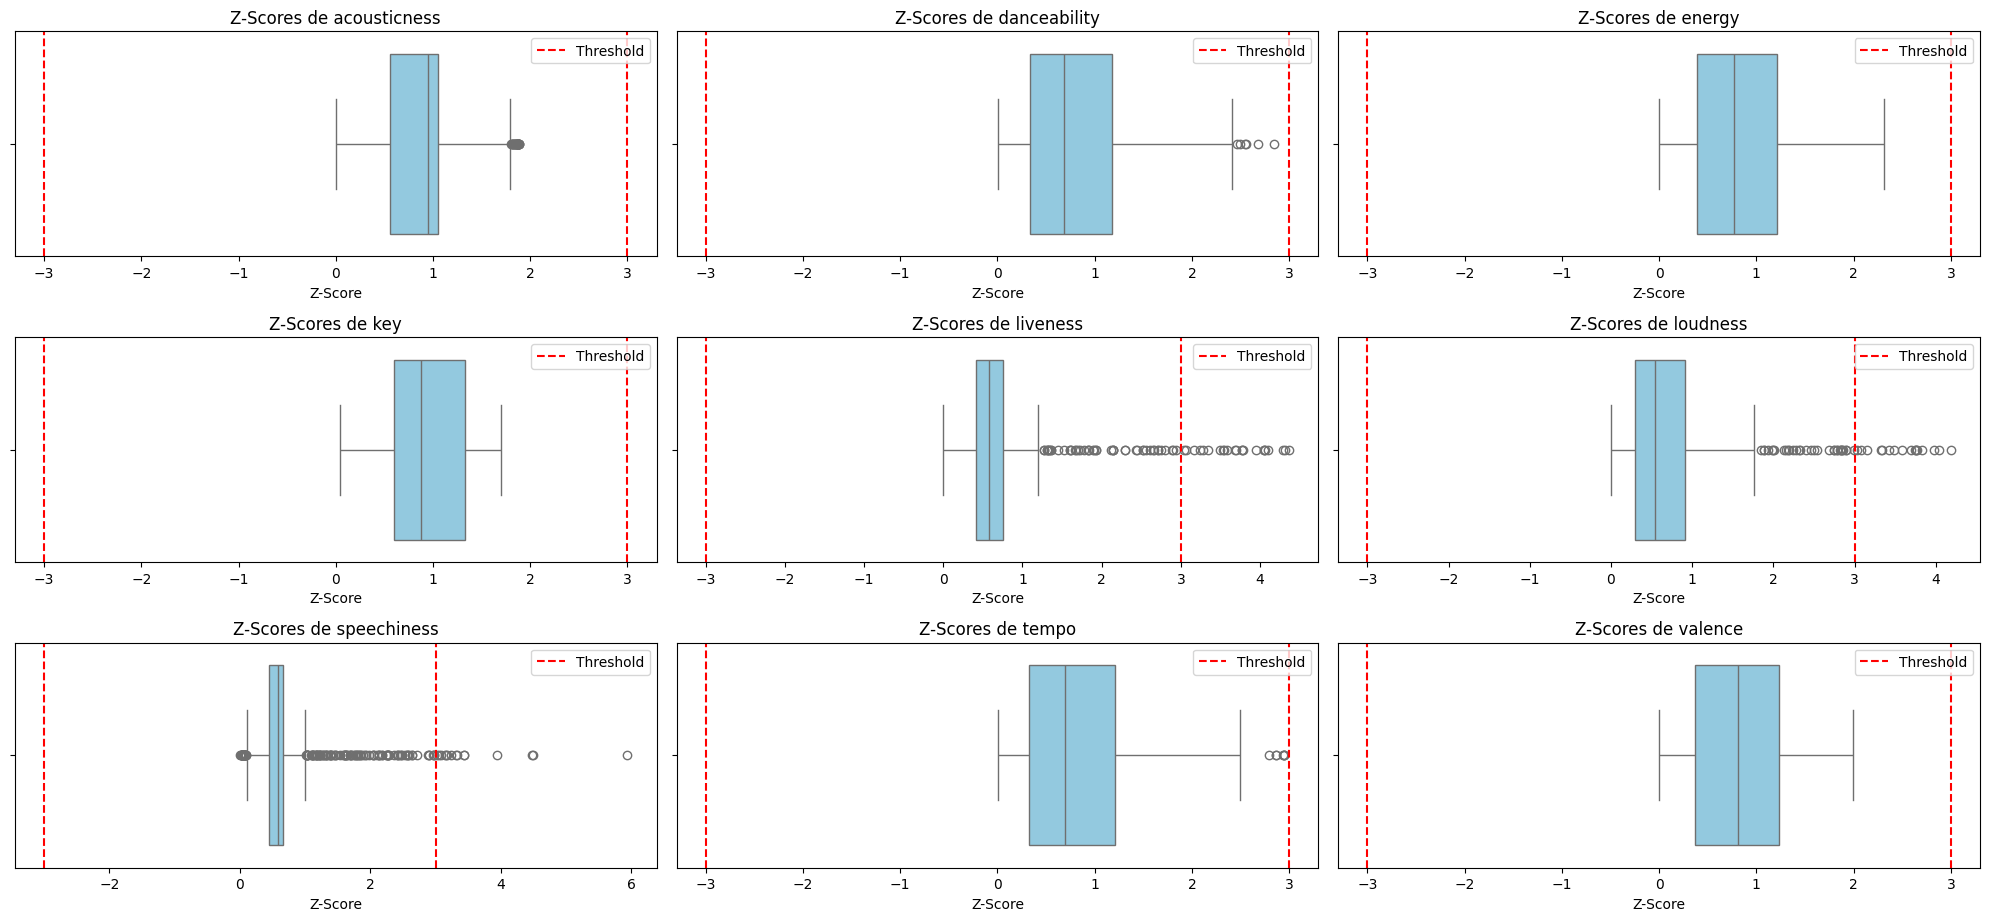

In [ ]:
threshold = 3

plt.figure(figsize=(20, 15))

for i, column in enumerate(df.select_dtypes(include=['float64', 'int64']).columns):
    if column != "label":
        z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())

        plt.subplot(5, 3, i + 1)
        sns.boxplot(x=z_scores, color='skyblue')
        plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
        plt.axvline(-threshold, color='red', linestyle='--')
        plt.title(f'Z-Scores de {column}')
        plt.xlabel('Z-Score')
        plt.legend()

plt.tight_layout()
plt.show()

Los Z-scores de las columnas **liveness**, **loudness** y **speechiness** tienen valores fuera del umbral de ±3 (threshold), lo que significa que en esas columnas hay valores que se consideran outliers de acuerdo con el método del Z-score. Estos valores están significativamente lejos del promedio de la distribución de sus respectivas columnas.

##### Método del rango intercuartil (IQR)

In [ ]:
def plot_outliers_scatter(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_idx = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index

    fig, ax = plt.subplots(1, figsize=(18, 6))
    ax.scatter(np.arange(0, df.shape[0]), df[column], color='g', label='Datos normales')
    ax.scatter(outliers_idx, df.loc[outliers_idx, column], color='r', label='Outliers')
    ax.axhline(lower_bound, color="r", linestyle="--", label='Límite inferior')
    ax.axhline(upper_bound, color="r", linestyle="--", label='Límite superior')

    ax.set_title(f'Detección de Outliers en {column}', fontsize=16)
    ax.set_xlabel('Índice', fontsize=12)
    ax.set_ylabel(f'Valores de {column}', fontsize=12)
    plt.legend()

    plt.show()

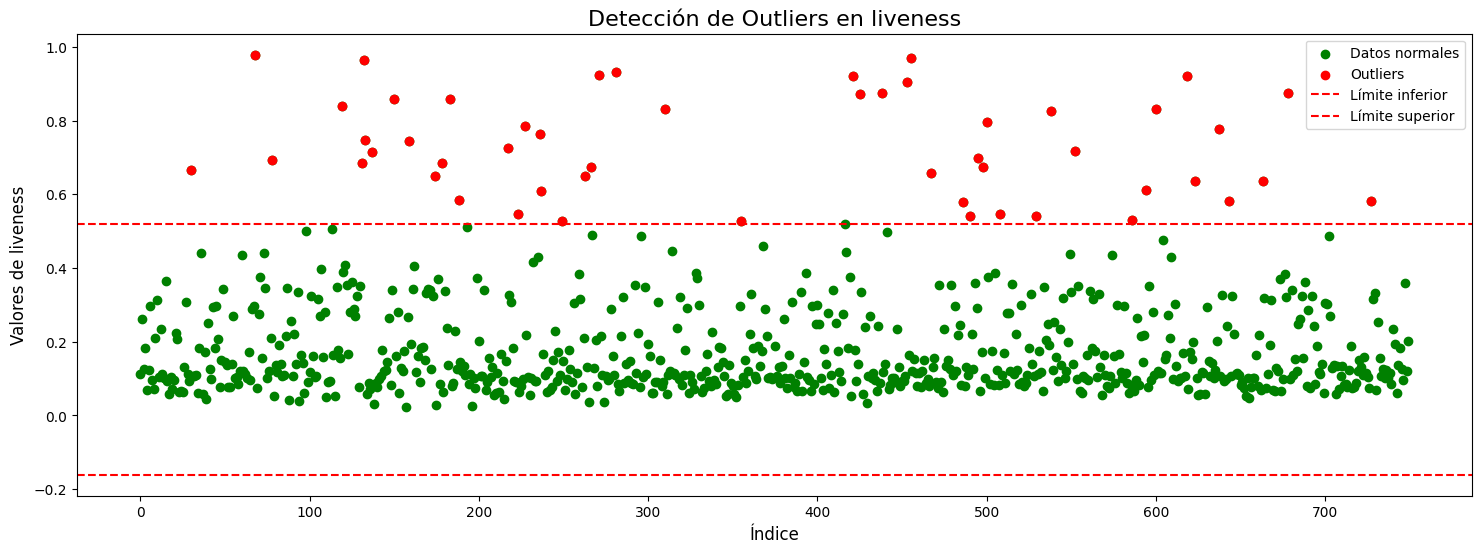

In [ ]:
plot_outliers_scatter(df, 'liveness')

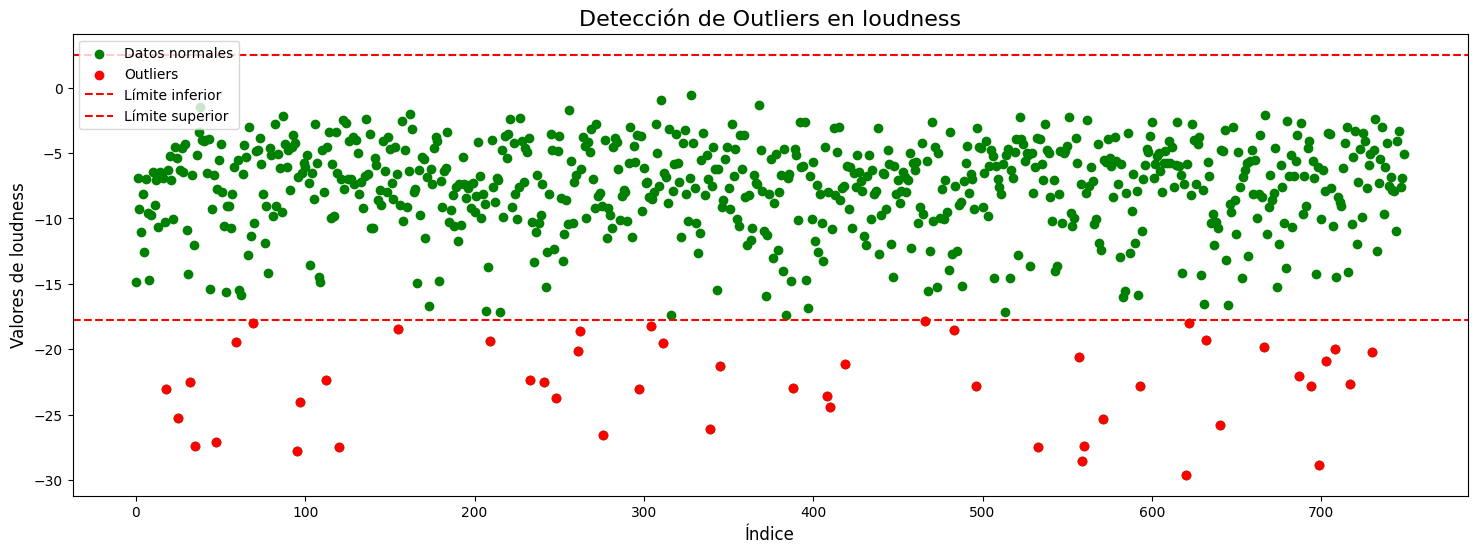

In [ ]:
plot_outliers_scatter(df, 'loudness')

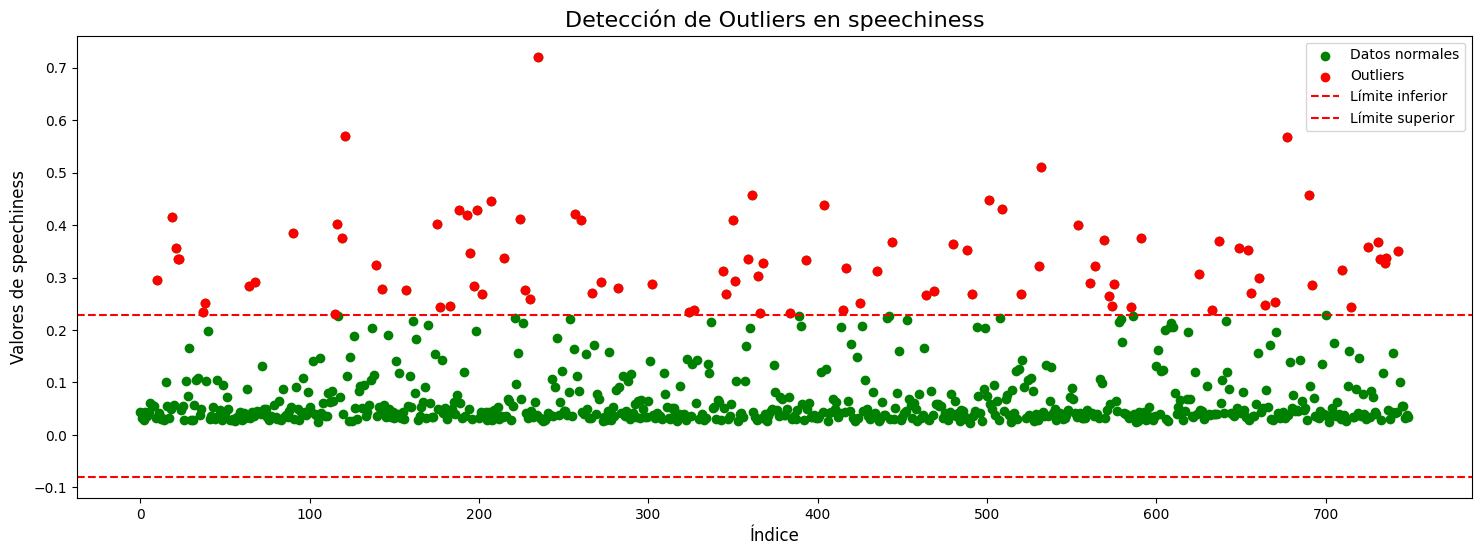

In [ ]:
plot_outliers_scatter(df, 'speechiness')

Porcentajes del dataset completo:

* **acousticness, energy, key, mode y valence (0%)**: no se requieren acciones, ya que no hay outliers.

* **danceability (0.13%) y tempo (0.93%)**: dado que estos porcentajes son muy bajos, vamos a ignorar estos outliers, ya que no tendrán un impacto significativo en el modelo.

* **liveness (6.8%) y loudness (6.53%)**: porcentajes moderadamente bajos.

* **speechiness (12.8%)**: este es un porcentaje relativamente alto.

### Tratamiento

Vamos a optar por aplicar **capping** para limitar el impacto de los valores extremos. Esto ayudará a mantener los outliers en el conjunto de datos pero a reducir su efecto extremo en el análisis.

In [ ]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
  if column == "speechiness" or column == "liveness" or column == "loudness":
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    print(f"Columna: {column}")
    print(f"Outliers después del capping:\n{len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])}\n")

Columna: liveness
Outliers después del capping:
0

Columna: loudness
Outliers después del capping:
0

Columna: speechiness
Outliers después del capping:
0



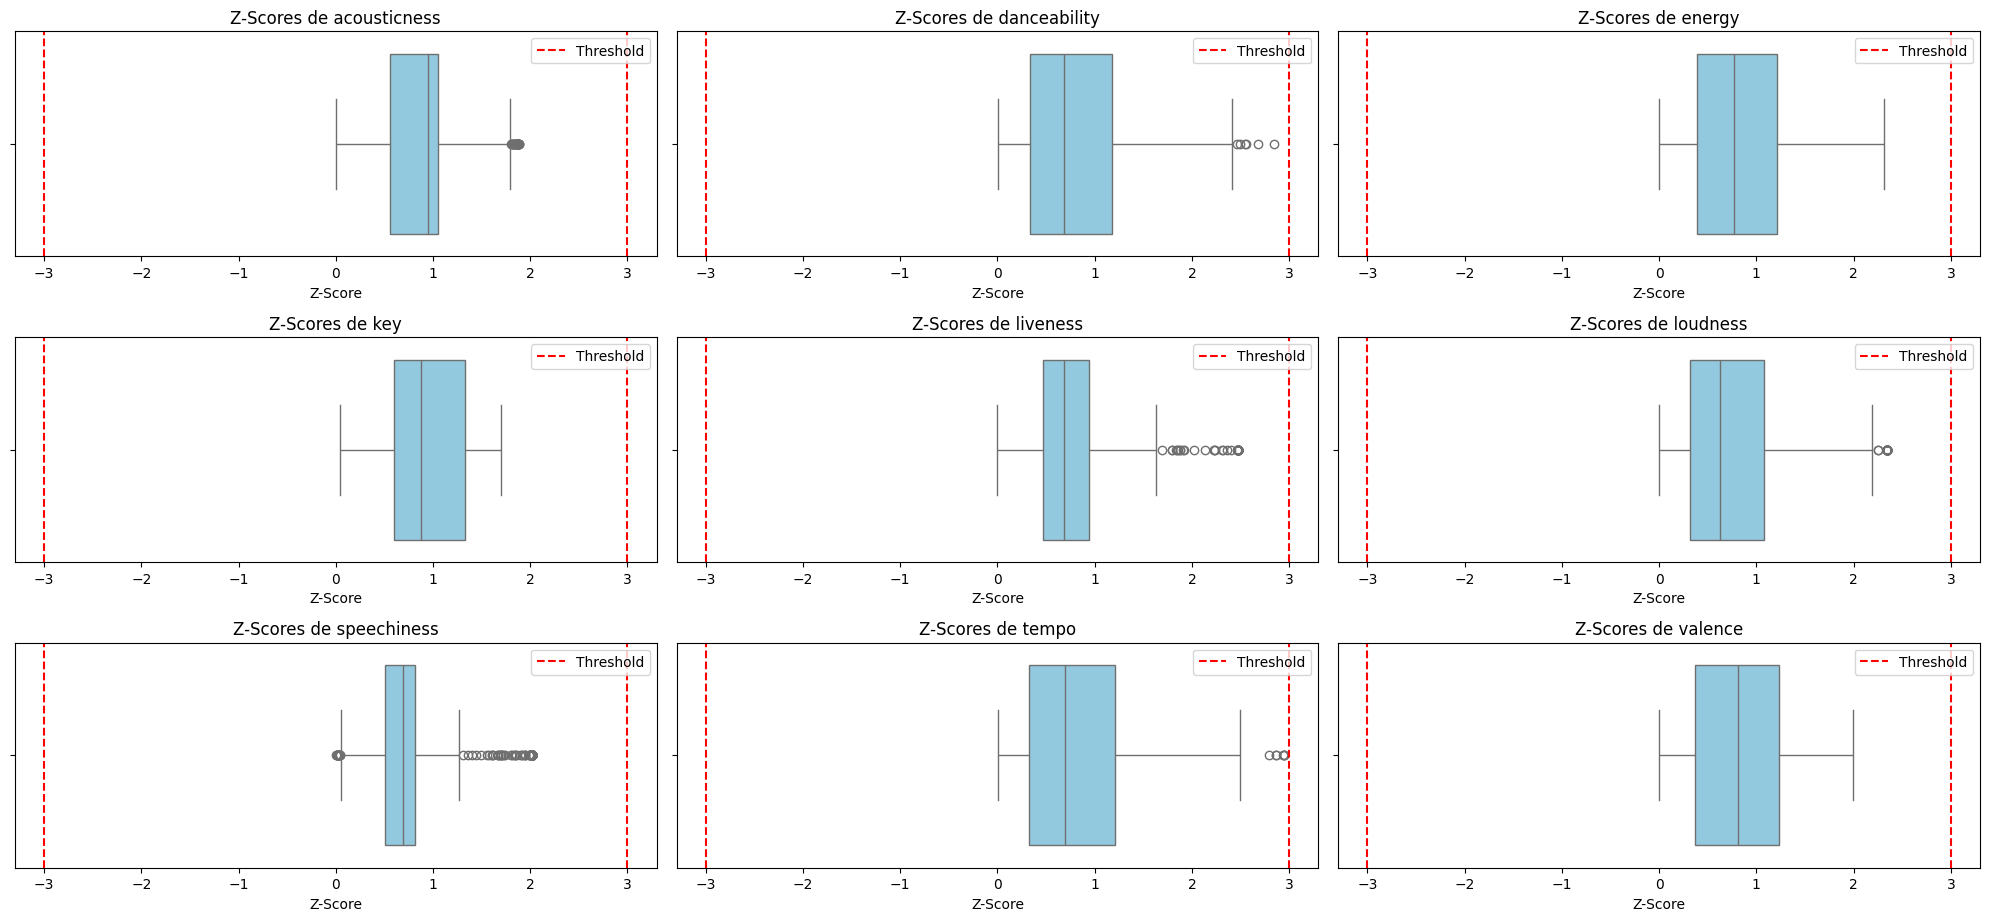

In [ ]:
threshold = 3

plt.figure(figsize=(20, 15))

for i, column in enumerate(df.select_dtypes(include=['float64', 'int64']).columns):
    if column != "label":
        z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())

        plt.subplot(5, 3, i + 1)
        sns.boxplot(x=z_scores, color='skyblue')
        plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
        plt.axvline(-threshold, color='red', linestyle='--')
        plt.title(f'Z-Scores de {column}')
        plt.xlabel('Z-Score')
        plt.legend()

plt.tight_layout()
plt.show()

### Transformación de variables

Se crean bandas para 3 features continuas:

**Tempo**: canciones con tempo lento (< 80 BPM), moderado (80-120 BPM), rápido(> 120 BPM)

In [ ]:
tempo_bands = pd.get_dummies(pd.cut(df['tempo'], bins=[0, 80, 120, float('inf')], labels=['tempo_slow', 'tempo_moderate', 'tempo_fast']))
df = pd.concat([df, tempo_bands], axis=1)

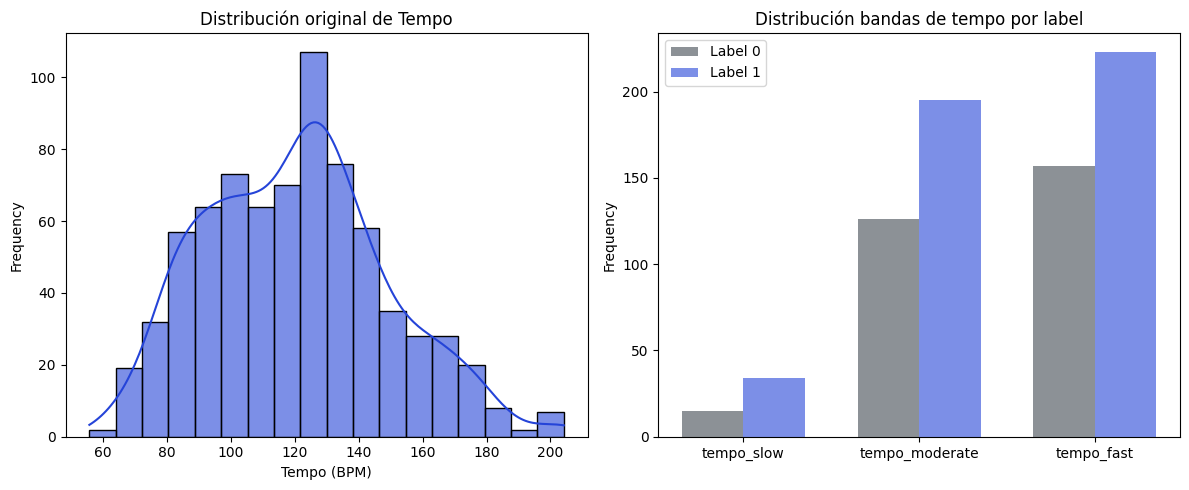

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['tempo'], kde=True, ax=axes[0], color='#2544d8', alpha=0.6)
axes[0].set_title('Distribución original de Tempo')
axes[0].set_xlabel('Tempo (BPM)')
axes[0].set_ylabel('Frequency')

tempo_bands_counts = df.groupby('label')[['tempo_slow', 'tempo_moderate', 'tempo_fast']].sum()

bar_width = 0.35
positions = np.arange(len(tempo_bands_counts.columns))

axes[1].bar(positions - bar_width/2, tempo_bands_counts.loc[0], width=bar_width, label='Label 0', color='#3f4850', alpha=0.6)
axes[1].bar(positions + bar_width/2, tempo_bands_counts.loc[1], width=bar_width, label='Label 1', color='#2544d8', alpha=0.6)

axes[1].set_title('Distribución bandas de tempo por label')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(tempo_bands_counts.columns)

axes[1].legend()

plt.tight_layout()
plt.show()

Como se puede ver, predominan las canciones con un tempo superior a 120 BPM y las canciones con tempo entre 80 y 120 BPM. Son pocas las canciones con un tempo lento. La distribucion original entre canciones gustadas y no gustadas se mantiene.

**Speechiness**: canciones sin vocales (< 0.20), con vocales e instrumentos (0.20 - 0.66), solo vocales (> 0.66)

In [ ]:
tempo_bands = pd.get_dummies(pd.cut(df['speechiness'], bins=[0, 0.20, 0.66, 1], labels=['speechiness_low', 'speechiness_moderate', 'speechiness_high']))
df = pd.concat([df, tempo_bands], axis=1)

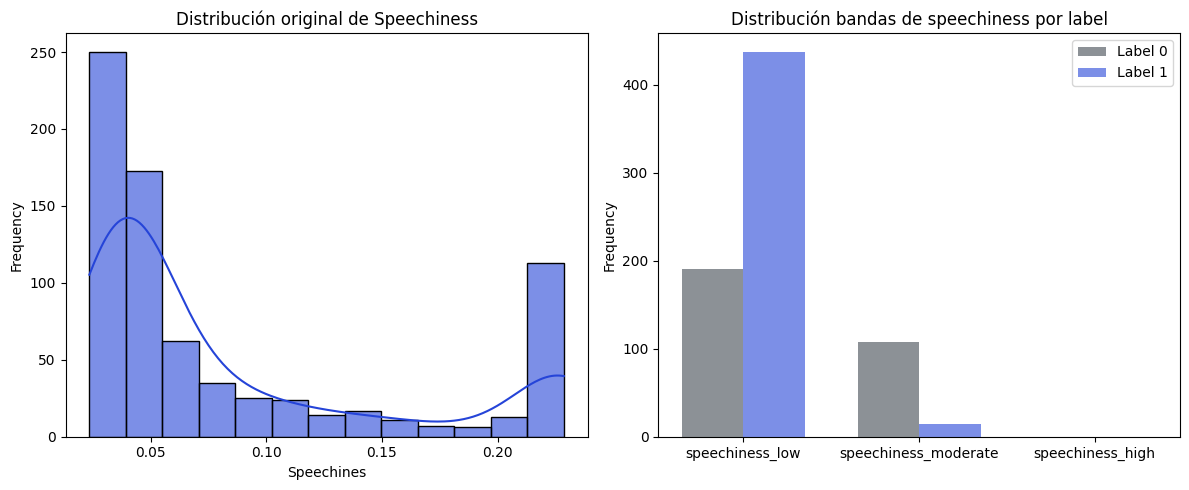

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['speechiness'], kde=True, ax=axes[0], color='#2544d8', alpha=0.6)
axes[0].set_title('Distribución original de Speechiness')
axes[0].set_xlabel('Speechines')
axes[0].set_ylabel('Frequency')

tempo_bands_counts = df.groupby('label')[['speechiness_low', 'speechiness_moderate', 'speechiness_high']].sum()

bar_width = 0.35
positions = np.arange(len(tempo_bands_counts.columns))

axes[1].bar(positions - bar_width/2, tempo_bands_counts.loc[0], width=bar_width, label='Label 0', color='#3f4850', alpha=0.6)
axes[1].bar(positions + bar_width/2, tempo_bands_counts.loc[1], width=bar_width, label='Label 1', color='#2544d8', alpha=0.6)

axes[1].set_title('Distribución bandas de speechiness por label')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(tempo_bands_counts.columns)

axes[1].legend()

plt.tight_layout()
plt.show()

Se observa la diferencia previamente vista. Hay una preferencia por canciones con speechiness bajo. Para speechiness medio, hay mas "dislikes". Se podria obviar la categoria de speechiness alto.

In [ ]:
# Features originales, previas a generar las bandas
df.drop(columns=['tempo'], inplace=True)
df.drop(columns=['speechiness'], inplace=True)

### Reducción de Dimensionalidad

Utilizaremos inicialmente la técnica 'Análisis de Componentes Principales' (PCA) para generar un nuevo dataset a partir de componentes que capturen el 95% de la varianza total. Luego, entrenaremos algunos modelos para comparar su desempeño con y sin reducción de dimensionalidad (es decir, con el dataset original y con el dataset creado por PCA).

A continuación un análisis gráfico simple que muestra cuánto influyen las variables en la explicación del valor de label.

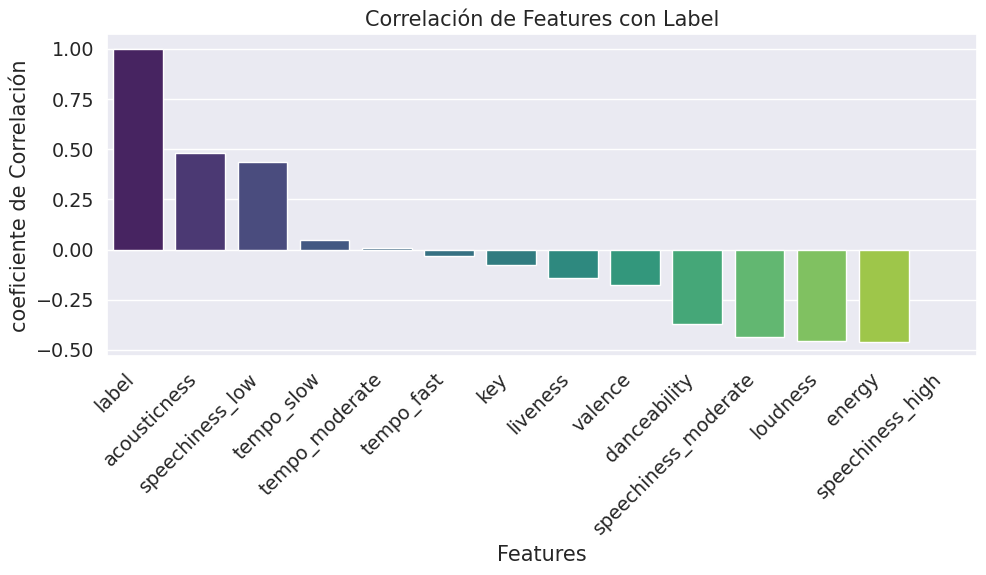

In [ ]:
# Calculamos la matríz de correlación
correlation_matrix = df.corr()

# Extraer y ordenar las correlaciones con 'label'
label_corr = correlation_matrix['label'].sort_values(ascending=False)

# Graficar las correlaciones con 'label'
plt.figure(figsize=(10, 6))
sns.barplot(x=label_corr.index, y=label_corr.values, hue=label_corr.index, palette='viridis', dodge=False, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Correlación de Features con Label')
plt.ylabel('coeficiente de Correlación')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

Usamos PCA para generar componentes cada uno de los cuales va a capturar cierta proporción de la varianza total.

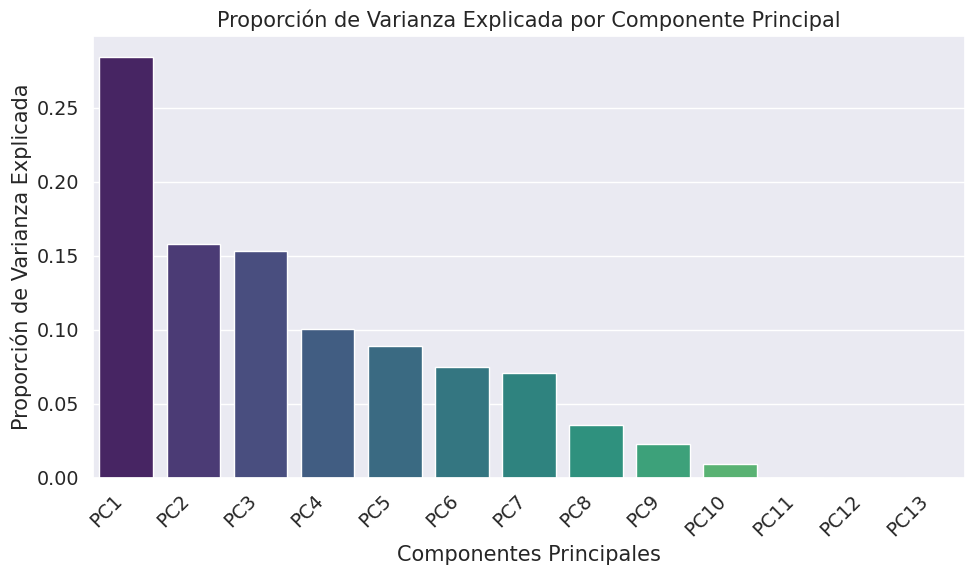

In [ ]:
# Separamos las features y el target
X = df.drop(columns=['label'])
y = df['label']

# Estandarizamos las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Proporción de varianza explicada para cada componente
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
sns.barplot(x=[f'PC{i+1}' for i in range(len(explained_variance_ratio))],
            y=explained_variance_ratio,
            hue=[f'PC{i+1}' for i in range(len(explained_variance_ratio))],
            palette='viridis',
            legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Proporción de Varianza Explicada por Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.tight_layout()

plt.show()

A continuación, seleccionamos el número óptimos de componentes que expliquen al menos el 95% de la varianza (que es la elección que hicimos sobre cuánta varianza queremos capturar).

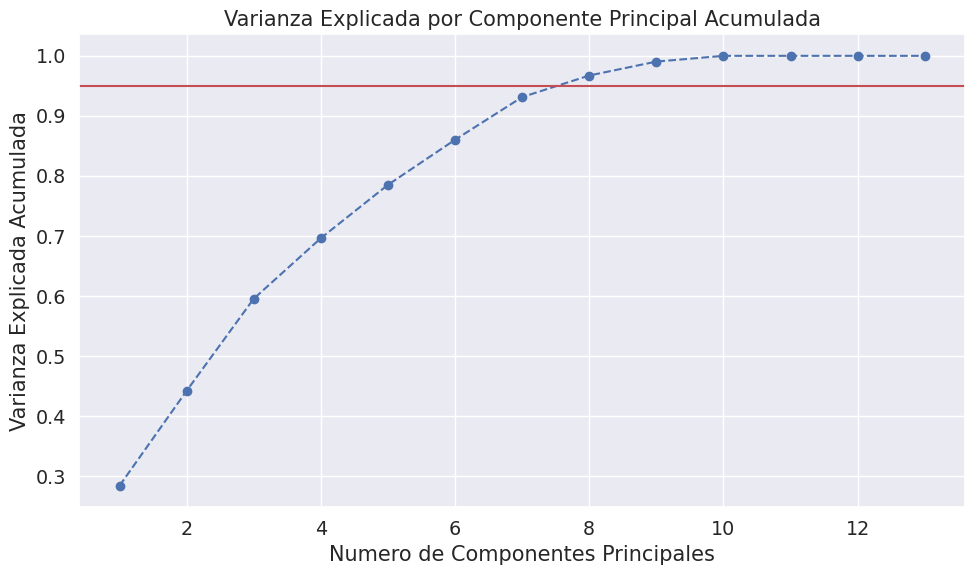

8

In [ ]:
# Separamos target y resto de features
X = df.drop(columns=['label'])
y = df['label']

# Estandarizamos las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA
pca = PCA()
pca.fit(X_scaled)

# Calculamos la razón de varianza explicada acumulada
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Ploteamos la razón de varianza explicada acumulada para encontrar el número óptimo de componentes
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Varianza Explicada por Componente Principal Acumulada')
plt.xlabel('Numero de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.tight_layout()
plt.show()

# Encontrar el número de componentes necesarios para explicar al menos el 95% de la varianza
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
n_components_95


En el gráfico se observa que con 7 componentes principales se alcanza un poco más del 95% de la varianza total, lo que indica que la mayor parte de la información en los datos originales puede ser capturada utilizando sólo estas 7 componentes.

In [ ]:
# Separamos target del resto de features
X = df.drop(columns=['label'])
y = df['label']

# Estandarizamos las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducimos dimensionalidad a 7 componentes
pca = PCA(n_components=7)
X_pca_reduced = pca.fit_transform(X_scaled)

# Separamos en train y test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.2, random_state=42)

# Entrenamos el modelo Logistic Regression
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

# Entrenamos el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluamos ambos modelos
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

logistic_report = classification_report(y_test, y_pred_logistic)
rf_report = classification_report(y_test, y_pred_rf)

#logistic_accuracy, rf_accuracy, logistic_report, rf_report

> **Accuracy** y **Report** utilizando dataset reducido con PCA.

In [ ]:
def get_metrics(first_model_r, first_model_name, second_model_name, second_model_r, first_model_acc, second_model_acc):

    acc_dict = {
        'Model': [first_model_name, second_model_name],
        'Accuracy': [first_model_acc, second_model_acc]
    }
    acc_df = pd.DataFrame(acc_dict)

    print(first_model_name, '\n', '-'*53, '\n', first_model_r, '\n',
          second_model_name, '\n', '-'*53, '\n', second_model_r)

    return acc_df

In [ ]:
get_metrics(logistic_report, 'Logistic Regression',
            'Random Forest', rf_report,
            logistic_accuracy, rf_accuracy)

Logistic Regression 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.72      0.76      0.74        54
           1       0.86      0.83      0.85        96

    accuracy                           0.81       150
   macro avg       0.79      0.80      0.79       150
weighted avg       0.81      0.81      0.81       150
 
 Random Forest 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.85      0.74      0.79        54
           1       0.86      0.93      0.89        96

    accuracy                           0.86       150
   macro avg       0.86      0.83      0.84       150
weighted avg       0.86      0.86      0.86       150



,Model,Accuracy
0,Logistic Regression,0.806667
1,Random Forest,0.860000


Entrenamos los mismos modelos con el dataset original

In [ ]:
# Dividimos el dataset original en conjuntos de training y testing (80% train, 20% test)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Entrenamos el modelo de Regresión Logística con los datos originales
logistic_model_orig = LogisticRegression(random_state=42)
logistic_model_orig.fit(X_train_orig, y_train_orig)
y_pred_logistic_orig = logistic_model_orig.predict(X_test_orig)

# Entrenamos el modelo Random Forest con los datos originales
rf_model_orig = RandomForestClassifier(random_state=42)
rf_model_orig.fit(X_train_orig, y_train_orig)
y_pred_rf_orig = rf_model_orig.predict(X_test_orig)

# Evalumos ambos modelos en los datos originales
logistic_accuracy_orig = accuracy_score(y_test_orig, y_pred_logistic_orig)
rf_accuracy_orig = accuracy_score(y_test_orig, y_pred_rf_orig)

logistic_report_orig = classification_report(y_test_orig, y_pred_logistic_orig)
rf_report_orig = classification_report(y_test_orig, y_pred_rf_orig)

#logistic_accuracy_orig, rf_accuracy_orig, logistic_report_orig, rf_report_orig

> **Accuracy** y **Report** para el dataset completo.

In [ ]:
get_metrics(logistic_report_orig, 'Logistic Regression',
            'Random Forest', rf_report_orig,
            logistic_accuracy_orig, rf_accuracy_orig)

Logistic Regression 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.68      0.74      0.71        54
           1       0.85      0.80      0.82        96

    accuracy                           0.78       150
   macro avg       0.76      0.77      0.77       150
weighted avg       0.79      0.78      0.78       150
 
 Random Forest 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        54
           1       0.89      0.89      0.89        96

    accuracy                           0.85       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.85      0.85      0.85       150



,Model,Accuracy
0,Logistic Regression,0.780000
1,Random Forest,0.853333


Ahora utilizaremos t-SNE para ver otra forma de reducir dimensionalidad y visualizar las relaciones entre los datos.

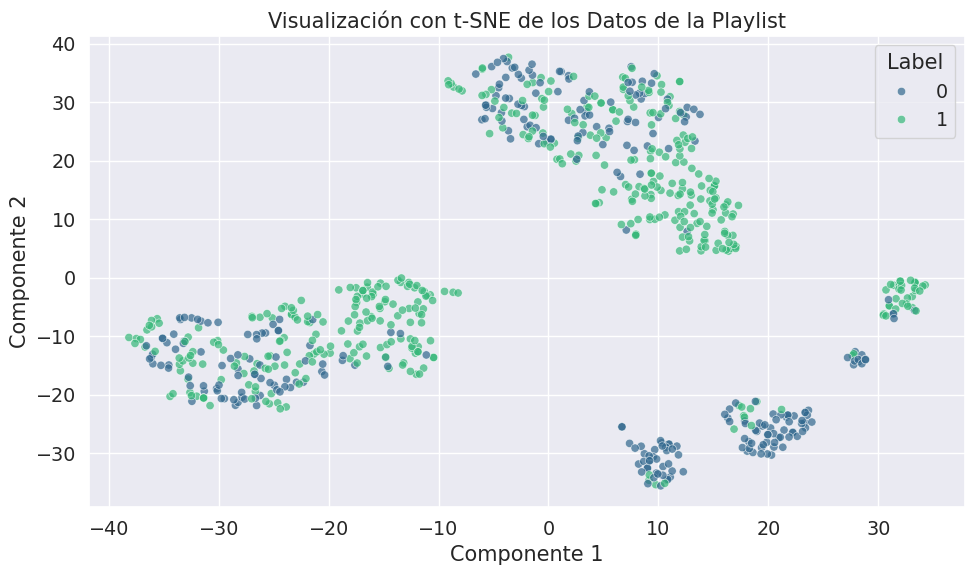

In [ ]:
# Aplicar t-SNE para reducir a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Crear un DataFrame con los resultados de t-SNE para visualización
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Ploteamos los resultados de t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne, x='Component 1', y='Component 2', hue='label', palette='viridis', alpha=0.7)
plt.title('Visualización con t-SNE de los Datos de la Playlist')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Label', loc='best')
plt.tight_layout()
plt.show()

Si bien se forman grupos de datos (canciones de la playlist con características similares), al estar los colores bastante mezclados en los clústers, podemos concluir que estos 2 componentes generados por t-SNE no siempre permiten diferenciar completamente entre las canciones preferidas y no preferidas.

También usaremos LDA (Análisis Discriminante Lineal) para experimentar con otra forma de reducir dimensionalidad y comparar.

Al ser binario el target (label) LDA tiene una sola dimensión.

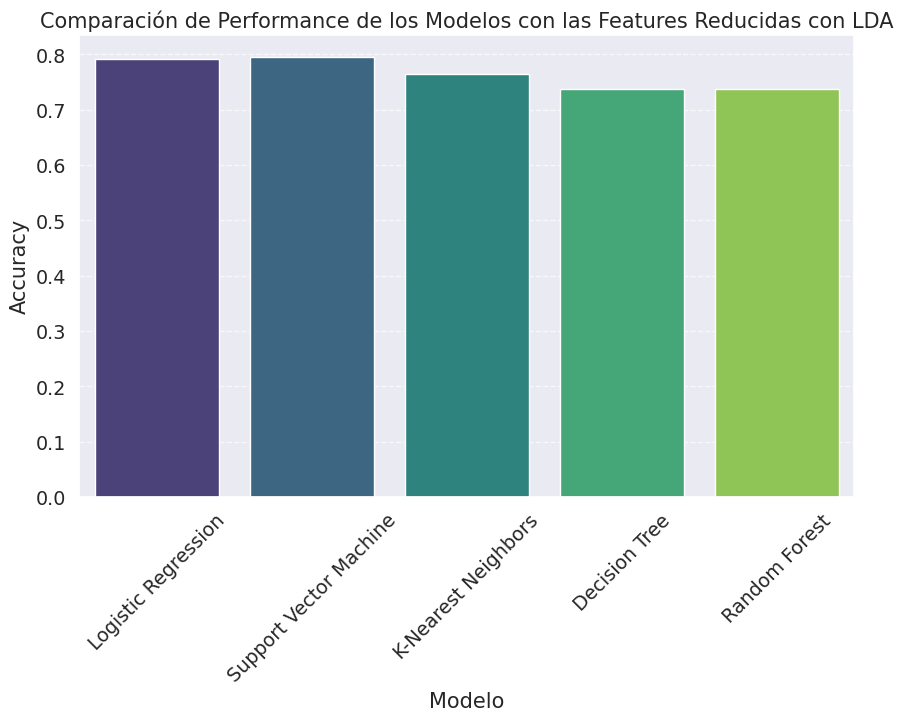

,Model,Accuracy
0,Logistic Regression,0.791111
1,Support Vector Machine,0.795556
2,K-Nearest Neighbors,0.764444
3,Decision Tree,0.737778
4,Random Forest,0.737778


In [ ]:
# Inicializar diferentes modelos para comparar
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}
# Aplicar LDA para reducir las dimensiones a 1 component (LDA con target binario tiene 1 dimensión)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

# Separar en training y test con las features reducidas con LDA
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda, y, test_size=0.3, random_state=42)

# Entrenar y evaluar los modelos con las features reducidas con LDA
lda_performance = {}

for model_name, model in models.items():
    model.fit(X_train_lda, y_train_lda)
    y_pred_lda = model.predict(X_test_lda)
    accuracy_lda = accuracy_score(y_test_lda, y_pred_lda)
    lda_performance[model_name] = accuracy_lda

# Crear un DataFrame con la performance de los modelos para comparar
lda_performance_df = pd.DataFrame(list(lda_performance.items()), columns=['Model', 'Accuracy'])

# Mostrar la performance de los modelos en un barchart para las features reducidas con LDA
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=lda_performance_df, hue='Model', palette='viridis', legend=False)
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.title('Comparación de Performance de los Modelos con las Features Reducidas con LDA')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Mostrar el DataFrame de performance
lda_performance_df


Por último, vamos a entrenar un **Árbol de Decisión** con el dataset original y luego con el dataset reducido por **PCA** con 7 componentes principales y luego vamos a comparar los resultados.

In [ ]:
# Separamos features y target
X = df.drop(columns=['label'])
y = df['label']

# Estandarizamos las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividimos en train y test (80% train, 20% test)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Entrenamos el Decision Tree en el dataset original
dt_model_orig = DecisionTreeClassifier(random_state=42)
dt_model_orig.fit(X_train_orig, y_train_orig)
y_pred_dt_orig = dt_model_orig.predict(X_test_orig)

# Evaluamos el Decision Tree en el dataset
dt_accuracy_orig = accuracy_score(y_test_orig, y_pred_dt_orig)
dt_report_orig = classification_report(y_test_orig, y_pred_dt_orig)

# Reducimos dimensionalidad a 7 componentes usando PCA
pca_7 = PCA(n_components=7)
X_pca_reduced_7 = pca_7.fit_transform(X_scaled)

# El dataset reducido lo spliteamos en train y test (80% train, 20% test)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_reduced_7, y, test_size=0.2, random_state=42)

# Entrenamos el Decision Tree en el dataset reducido (7 componentes)
dt_model_pca = DecisionTreeClassifier(random_state=42)
dt_model_pca.fit(X_train_pca, y_train_pca)
y_pred_dt_pca = dt_model_pca.predict(X_test_pca)

# Evaluamos el Decision Tree en el dataset reducido (7 componentes)
dt_accuracy_pca = accuracy_score(y_test_pca, y_pred_dt_pca)
dt_report_pca = classification_report(y_test_pca, y_pred_dt_pca)

# Mostramos los resultados
#dt_accuracy_orig, dt_accuracy_pca, dt_report_orig, dt_report_pca


**Accuracy** y **Report** para Dataset Original y para Dataset reducido con PCA.

In [ ]:
get_metrics(dt_report_orig, 'Decision Tree (dataset original)',
            'Decision Tree (PCA)', dt_report_pca,
            dt_accuracy_orig, dt_accuracy_pca)

Decision Tree (dataset original) 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.66      0.74      0.70        54
           1       0.84      0.78      0.81        96

    accuracy                           0.77       150
   macro avg       0.75      0.76      0.75       150
weighted avg       0.78      0.77      0.77       150
 
 Decision Tree (PCA) 
 ----------------------------------------------------- 
               precision    recall  f1-score   support

           0       0.64      0.72      0.68        54
           1       0.83      0.77      0.80        96

    accuracy                           0.75       150
   macro avg       0.74      0.75      0.74       150
weighted avg       0.76      0.75      0.76       150



,Model,Accuracy
0,Decision Tree (dataset original),0.766667
1,Decision Tree (PCA),0.753333


**Interpretación de los resultados**

El modelo entrenado con el **dataset original** muestra una **exactitud del 76.67%**, mientras que el **modelo entrenado con PCA** tiene una exactitud ligeramente inferior, del **75.33%**. En este caso, podríamos trabajar sólo con el dataset reducido con PCA, si bien la métrica *precision* baja ligeramente, se reduce la complejidad computacional porque se ocupan la mitad de las variables (7 componentes principales).


Graficamos el arbol para el modelo entrenado con el dataset original

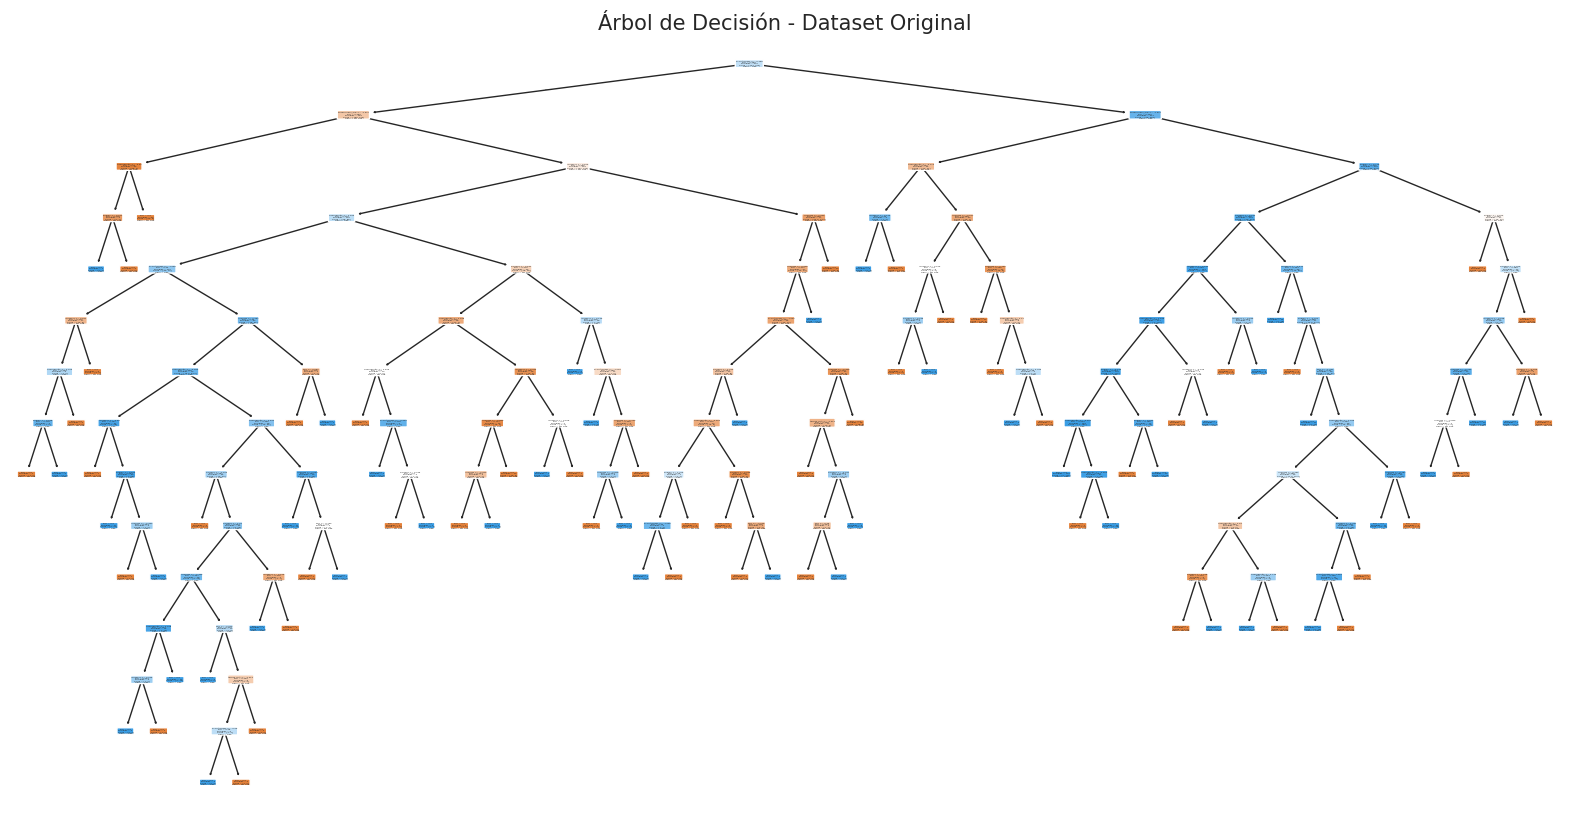

In [ ]:
# Graficar el árbol de decisión para el modelo entrenado con el dataset original
plt.figure(figsize=(20, 10))
plot_tree(dt_model_orig, filled=True, feature_names=X.columns, class_names=['No Like', 'Like'], rounded=True)
plt.title("Árbol de Decisión - Dataset Original")
plt.show()


Graficamos el arbol para el modelo entrenado con el dataset reducido por pca

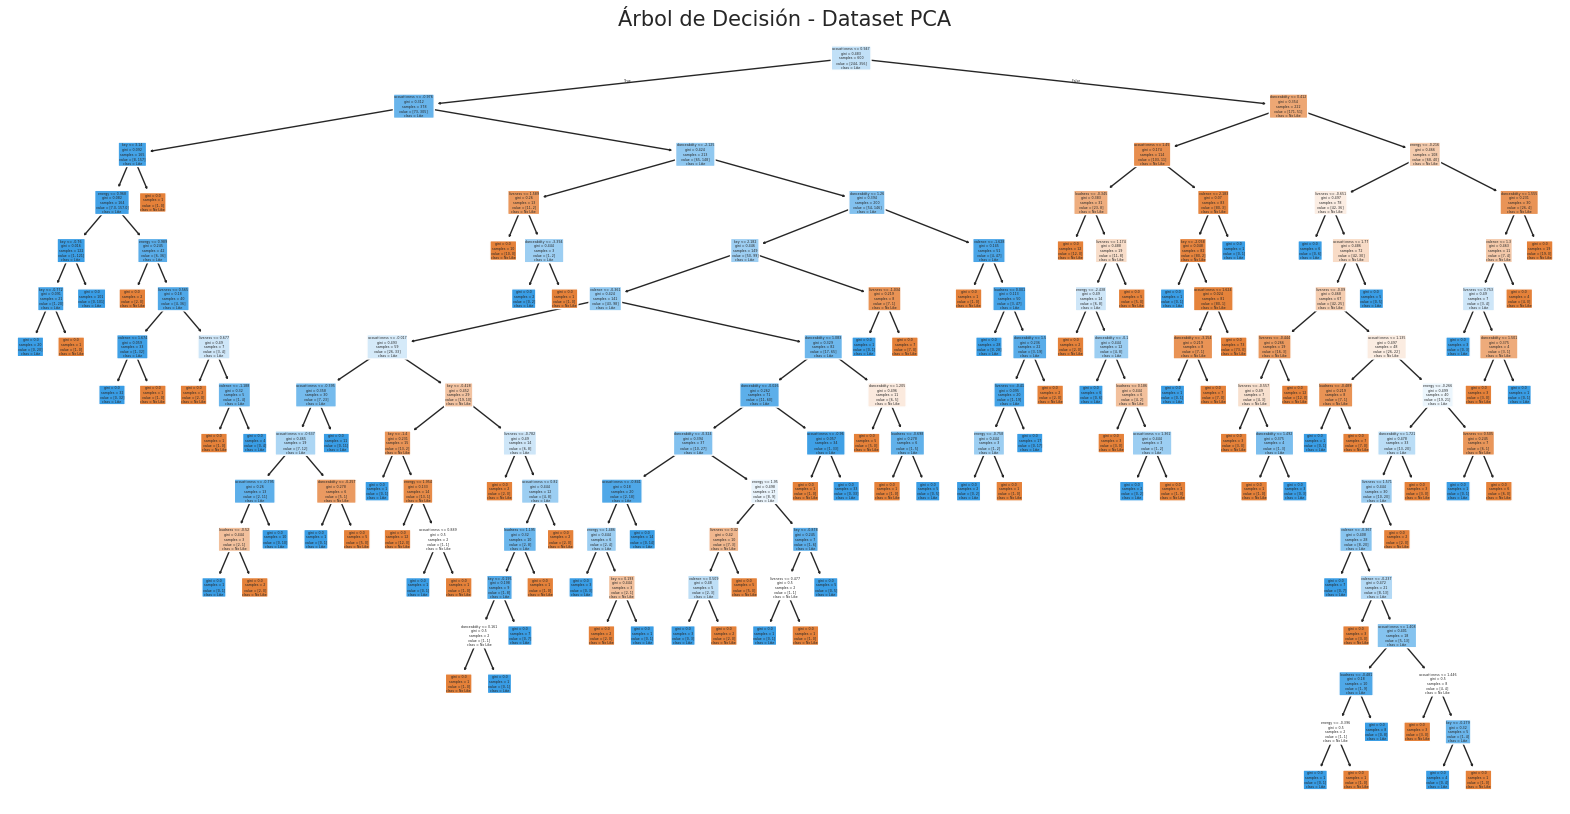

In [ ]:
# Graficar el árbol de decisión para el modelo entrenado con el dataset original
plt.figure(figsize=(20, 10))
plot_tree(dt_model_pca, filled=True, feature_names=X.columns, class_names=['No Like', 'Like'], rounded=True)
plt.title("Árbol de Decisión - Dataset PCA")
plt.show()

Esta prueba, sólo a efectos de visualización, con el dataset original y limitando la profundidad a 4

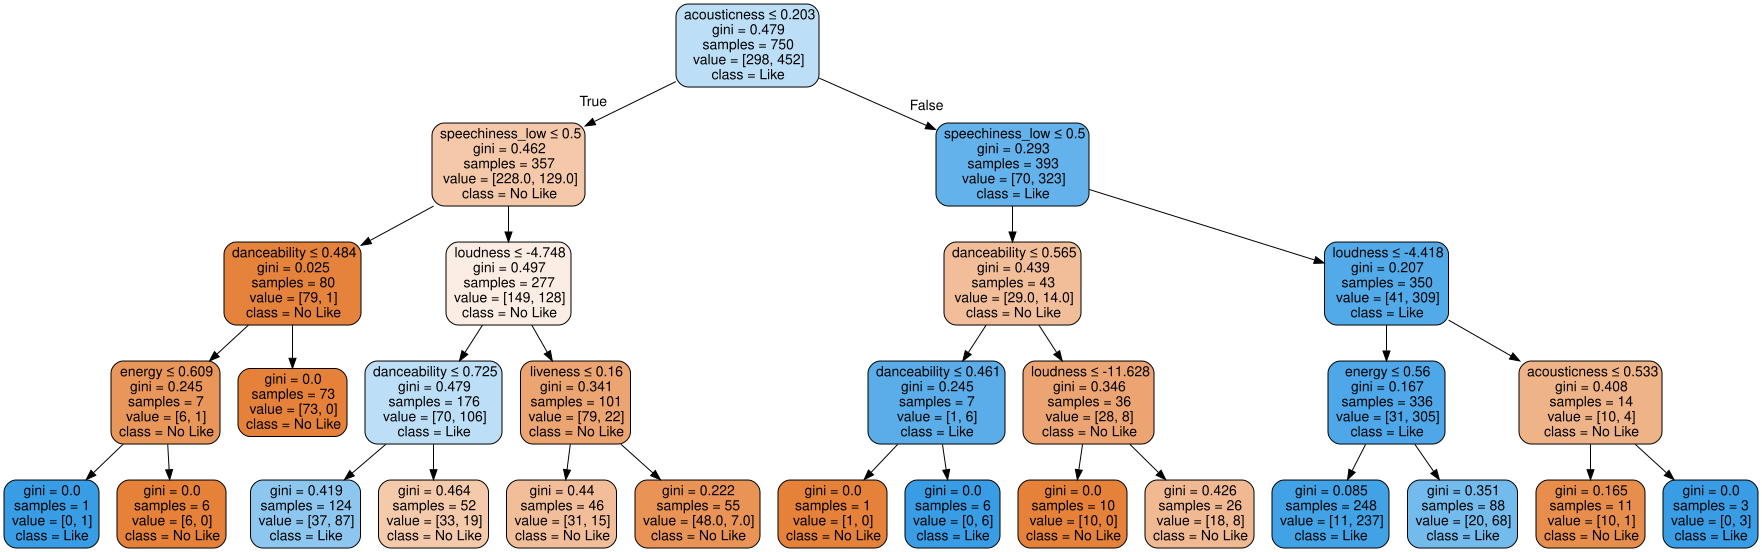

In [ ]:
X = df.drop('label', axis=1)

clf = DecisionTreeClassifier(random_state=42, criterion='gini',max_depth=4)
clf.fit(X, df['label'])

dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X.columns,
                           class_names=['No Like', 'Like'],
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph

Esta prueba, sólo a efectos de visualización, con el dataset reducido por pca con 7 componentes y limitando la profundidad a 4

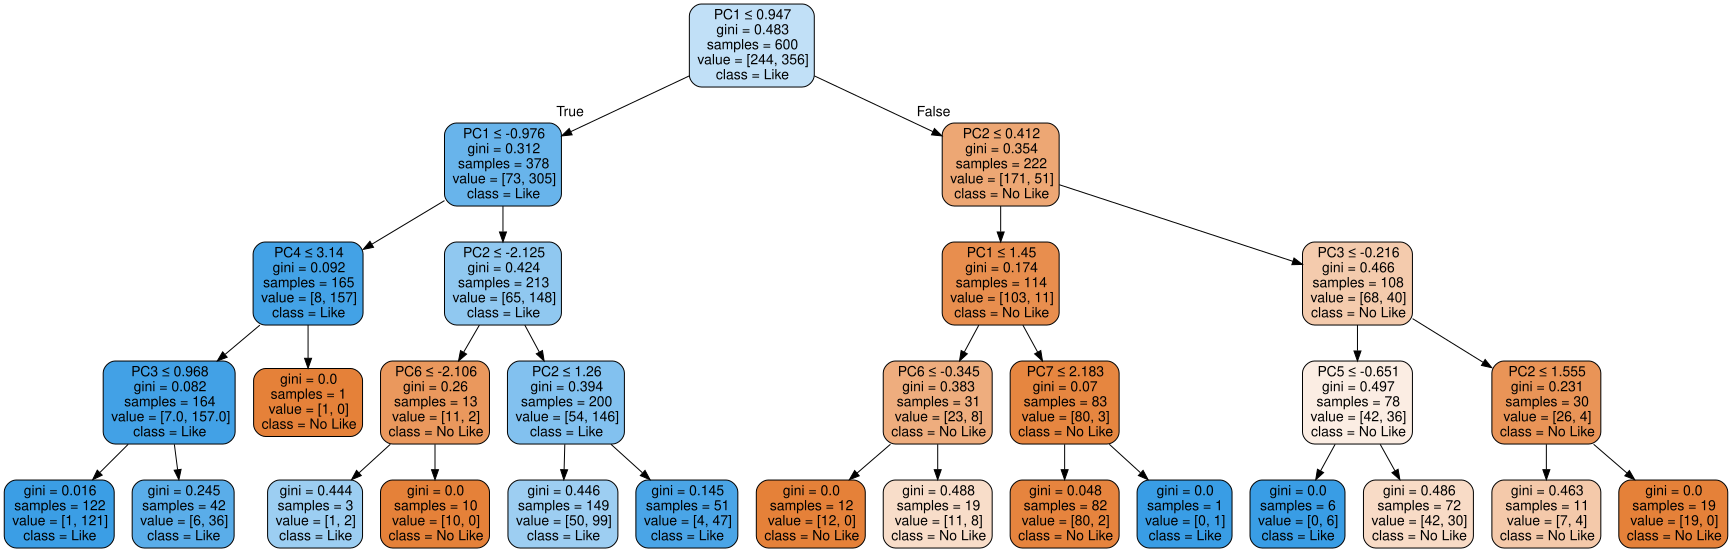

In [ ]:
clf_pca = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=4)
clf_pca.fit(X_train_pca, y_train_pca)
feature_names_pca = [f'PC{i+1}' for i in range(7)]

dot_data = export_graphviz(clf_pca, out_file=None,
                           feature_names=feature_names_pca,
                           class_names=['No Like', 'Like'],
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph

## Entrenamiento de modelos de Machine Learning

Como las features cuentan con diferentes distribuciones y rangos, se procederá a escalar las mismas utilizando un Standard Scaler.

A su vez, se utiza un split del set de datos de 70/30 entre entrenamiento y testeo.

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

Los modelos elegidos para entrenar son los siguientes:


*   Regresión Logística
*   KNN
*   Árbol de decisión
*   LightGBM
*   XGBoost
*   Random Forest



### Búsqueda de Hiperparámetros

Para automatizar la selección de hiperparámetros se procederá a utilizar Optuna. Se ejecutarán 200 pruebas para encontrar los hiperparámetros de cada modelo. Más adelante se definirán las funciones objetivo para cada modelo en particular.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.4 MB/s eta 0:00:00


In [ ]:
import optuna

def find_best_hyperparams(model_name, objective_function, n_trials=200):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_function, n_trials=n_trials)

    print(f'Number of finished trials for {model_name}:', len(study.trials))
    print(f'Best trial for {model_name}:', study.best_trial.params)
    print(f'Best value for {model_name}:', study.best_value)

    return study.best_trial.params

### Modelos Simples


*   Logistic Regression
*   K-Neighbors Classifier
*   Decision Tree Classifier



A continuación se definen las funciones objetivo para los 3 modelos iniciales.

Como se puede apreciar, cada modelo define los hiperparámetros a ajustar y utiliza el f1 score como metrica a maximizar.

La **regresión logistica** se entrenará en primera instancia por su sencillez y facilidad de interpretar. Se podrá utilizar como linea de base para su posterior comparación con otros modelos.

In [ ]:
def objective_logistic_regression(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10.0),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga'])
    }
    model = LogisticRegression(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

Entrenamos un modelo de **K-Neighbors** ya que las canciones que le gustan o no al usuario podrían estar agrupadas en clusters.

Podría ocurrir que al usuario le gusten un cierto tipo de canciones que comparten valores específicos de las características musicales.

In [ ]:
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)


Como último modelo simple optamos por un **Decision Tree** ya que es capaz de capturar relaciones no lineales entre las features y es muy simple de interpretar


In [ ]:
def objective_decision_tree(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
    }
    model = DecisionTreeClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

In [ ]:
best_params_logistic = find_best_hyperparams("Logistic Regression", objective_logistic_regression)
best_params_knn = find_best_hyperparams("KNN", objective_knn)
best_params_decision_tree = find_best_hyperparams("Decision Tree", objective_decision_tree)

[I 2024-10-21 01:21:04,877] A new study created in memory with name: no-name-8d8ce112-8e54-4206-a86a-983dc4fe41f9
[I 2024-10-21 01:21:04,899] Trial 0 finished with value: 0.8058608058608059 and parameters: {'C': 8.204575177085244, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.8058608058608059.
[I 2024-10-21 01:21:04,912] Trial 1 finished with value: 0.8058608058608059 and parameters: {'C': 4.2939823277449545, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.8058608058608059.
[I 2024-10-21 01:21:04,923] Trial 2 finished with value: 0.8058608058608059 and parameters: {'C': 4.907524151115769, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.8058608058608059.
[I 2024-10-21 01:21:04,932] Trial 3 finished with value: 0.8058608058608059 and parameters: {'C': 9.466660501971477, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.8058608058608059.
[I 2024-10-21 01:21:04,941] Trial 4 finished with value: 0.805860805860

Number of finished trials for Logistic Regression: 200
Best trial for Logistic Regression: {'C': 0.010238942543123339, 'penalty': 'l2', 'solver': 'saga'}
Best value for Logistic Regression: 0.8297872340425532


[I 2024-10-21 01:21:09,546] Trial 9 finished with value: 0.8285714285714286 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'algorithm': 'ball_tree'}. Best is trial 1 with value: 0.8472222222222222.
[I 2024-10-21 01:21:09,564] Trial 10 finished with value: 0.8368794326241135 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 1 with value: 0.8472222222222222.
[I 2024-10-21 01:21:09,582] Trial 11 finished with value: 0.8461538461538461 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 1 with value: 0.8472222222222222.
[I 2024-10-21 01:21:09,599] Trial 12 finished with value: 0.8387096774193549 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 1 with value: 0.8472222222222222.
[I 2024-10-21 01:21:09,616] Trial 13 finished with value: 0.8461538461538461 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial

Number of finished trials for KNN: 200
Best trial for KNN: {'n_neighbors': 4, 'weights': 'distance', 'algorithm': 'ball_tree'}
Best value for KNN: 0.8531468531468531


[I 2024-10-21 01:21:15,753] Trial 12 finished with value: 0.8504983388704319 and parameters: {'max_depth': 3, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8513513513513513.
[I 2024-10-21 01:21:15,787] Trial 13 finished with value: 0.8504983388704319 and parameters: {'max_depth': 3, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8513513513513513.
[I 2024-10-21 01:21:15,824] Trial 14 finished with value: 0.8044280442804428 and parameters: {'max_depth': 8, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.8513513513513513.
[I 2024-10-21 01:21:15,861] Trial 15 finished with value: 0.8344827586206897 and parameters: {'max_depth': 5, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8513513513513513.
[I 2024-10-21 01:21:15,892] Trial 16 finished with value: 0.8134328358208955 and 

Number of finished trials for Decision Tree: 200
Best trial for Decision Tree: {'max_depth': 4, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 1}
Best value for Decision Tree: 0.8551236749116607


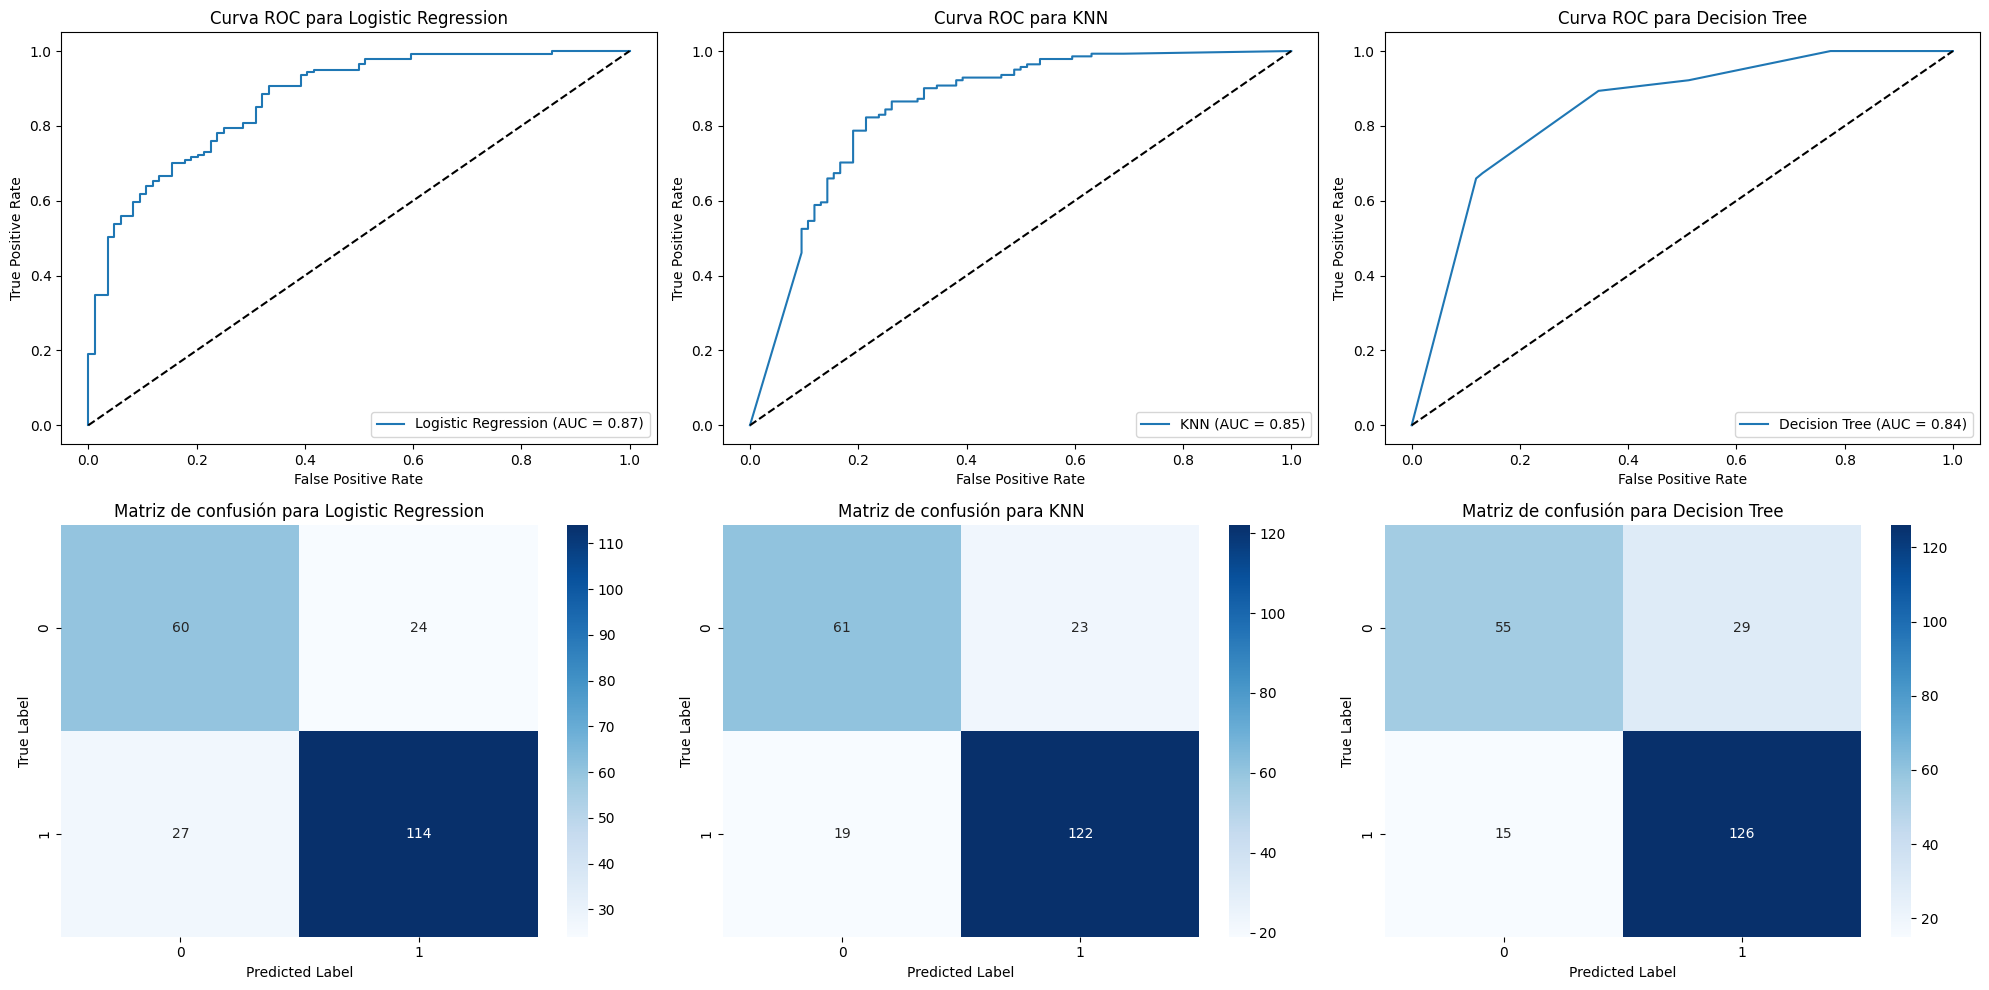

In [ ]:
models = [
    ("Logistic Regression", LogisticRegression(**best_params_logistic), X_train, y_train),
    ("KNN", KNeighborsClassifier(**best_params_knn), X_train, y_train),
    ("Decision Tree", DecisionTreeClassifier(**best_params_decision_tree), X_train, y_train),
]
fig, axes = plt.subplots(nrows=2, ncols=len(models), figsize=(20, 10))

for idx, (model_name, model, X_train, y_train) in enumerate(models):
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    axes[0, idx].plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    axes[0, idx].plot([0, 1], [0, 1], 'k--')
    axes[0, idx].set_title(f'Curva ROC para {model_name}')
    axes[0, idx].set_xlabel('False Positive Rate')
    axes[0, idx].set_ylabel('True Positive Rate')
    axes[0, idx].legend(loc='lower right')

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, idx])
    axes[1, idx].set_title(f'Matriz de confusión para {model_name}')
    axes[1, idx].set_xlabel('Predicted Label')
    axes[1, idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()


### Conclusiones de lo observado en las curvas ROC y matrices de confusión:
El modelo de **Regresión Logística** tiene un AUC de 0.86, lo que lo convierte en un buen discriminador entre las clases.
En términos de predicciones, la sensibilidad es muy alta (95%), lo que significa que detecta la mayoría de los casos positivos (clase 1). La precisión es un poco más baja (75.3%), lo que indica que hay algunos falsos positivos.
La matríz de confusión revela que el modelo tiene problemas al predecir correctamente la clase negativa (40 verdaderos negativos frente a 44 falsos positivos), lo cual podría mejorarse ajustando el umbral de decisión o mediante la optimización de otros hiperparámetros.

El modelo **KNN** presenta un AUC de 0.85, lo que indica que su capacidad de discriminación es buena, aunque un poco menor que la del modelo de regresión logística.
La exactitud del modelo (81.3%) es ligeramente mejor que la de la regresión logística (77.3%), lo que sugiere que el modelo de KNN realiza mejores predicciones en general.
La precisión del modelo KNN (84.1%) es mayor que la de la regresión logística (75.3%), lo que indica que el modelo comete menos falsos positivos.
Sin embargo, la sensibilidad del modelo KNN (86.5%) es menor que la del modelo de regresión logística (95%), lo que significa que KNN es menos eficaz en la detección de casos positivos (más falsos negativos).
En general, el modelo KNN parece ser un poco más equilibrado en términos de precisión y sensibilidad, y tiene un mejor rendimiento en la predicción de la clase negativa (más verdaderos negativos y menos falsos positivos).

El modelo de **Árbol de Decisión** presenta un AUC de 0.83, el más bajo de los tres modelos evaluados, lo que sugiere que tiene un rendimiento inferior en la discriminación entre clases en comparación con KNN y Regresión Logística.
En cuanto a la exactitud, el Árbol de Decisión tiene un valor similar a KNN (80.8% vs 81.3%) y superior a la regresión logística (77.3%).
La precisión del Árbol de Decisión (84%) es casi igual a la de KNN (84.1%) y superior a la de la regresión logística (75.3%), lo que significa que ambos modelos (KNN y Árbol de Decisión) cometen menos falsos positivos.
La sensibilidad del modelo de Árbol de Decisión (85.8%) es cercana a la de KNN (86.5%) pero inferior a la de la regresión logística (95%), lo que indica que podría estar dejando pasar algunos casos positivos.
En general, aunque el Árbol de Decisión muestra una precisión y sensibilidad competitivas, su AUC más bajo indica que es menos efectivo en términos generales para la tarea de clasificación en comparación con los otros dos modelos.

###Resumen Comparativo:
**Regresión Logística**: Mejor AUC (0.86) y alta sensibilidad (95%), pero precisión moderada (75.3%).

**KNN**: Buen balance entre precisión (84.1%) y sensibilidad (86.5%), y AUC aceptable (0.85).

**Árbol de Decisión**: Rendimiento similar al de KNN en cuanto a precisión y sensibilidad, pero menor AUC (0.83), lo que indica un rendimiento general más bajo.

En resumen, para esta tarea de clasificación, el modelo de Regresión Logística destaca por su capacidad de discriminación (AUC más alto), mientras que KNN y Árbol de Decisión tienen un mejor equilibrio entre precisión y sensibilidad.

### Modelos de ensemble


*   LightGBM
*   XGBoost
*   Random Forest

A continuación se definen las funciones objetivo para los 3 modelos de ensamble.

Como se puede apreciar, cada modelo define los hiperparámetros a ajustar y utiliza el f1 score como metrica a maximizar.

Como primer modelo de ensamble se eligió **Random Forest** para comenzar a capturar relaciones más complejas entre features y reducir overfitting en comparación al modelo simple de Arbol de decisión.

In [ ]:
def objective_random_forest(trial):
  params = {
    'n_estimators': trial.suggest_int("n_estimators", 10, 200, log=True),
    'max_depth': trial.suggest_int("max_depth", 2, 32),
    'min_samples_split': trial.suggest_int("min_samples_split", 2, 10),
    'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 10)
  }

  model = RandomForestClassifier(**params)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  return f1_score(y_test, y_pred)

Se decidió entrenar un modelo de **LightGBM** a continuación por su eficiencia a la hora de entrenar y evaluar.
Su tiempo de entrenamiento y busqueda de hiperparametros será mucho menor que los otros dos modelos de ensamble (Sin embargo, al contar con un dataset relativamente reducido, los tiempos de entrenamiento no serán elevados)

In [ ]:
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)

    }
    model = LGBMClassifier(**params, verbose=-1) # verbose=-1
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

Por último, el modelo más complejo de los de ensamble, **XGBoost**. Se busca una mayor precisión a costa de un mayor tiempo de entrenamiento (el cual no es un problema por las dimensiones del set de datos)

In [ ]:
def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

In [ ]:
best_params_lgbm = find_best_hyperparams("LightGBM", objective_lgbm)
best_params_xgb = find_best_hyperparams("XGBoost", objective_xgb)
best_params_random_forest = find_best_hyperparams("Random Forest", objective_random_forest)

[I 2024-10-21 01:29:34,239] A new study created in memory with name: no-name-88c52154-373f-4b4f-833d-ba8eb48cdbce
[I 2024-10-21 01:29:34,295] Trial 0 finished with value: 0.8296296296296296 and parameters: {'n_estimators': 159, 'learning_rate': 0.053901709234995744, 'max_depth': 5, 'num_leaves': 101, 'min_child_samples': 45, 'subsample': 0.9108248044556808, 'colsample_bytree': 0.6943317765225326, 'reg_alpha': 0.32459367602257116, 'reg_lambda': 0.028604093036122658}. Best is trial 0 with value: 0.8296296296296296.
[I 2024-10-21 01:29:34,355] Trial 1 finished with value: 0.8363636363636363 and parameters: {'n_estimators': 171, 'learning_rate': 0.026505934310255684, 'max_depth': 5, 'num_leaves': 110, 'min_child_samples': 19, 'subsample': 0.7588573149956699, 'colsample_bytree': 0.5176188903581087, 'reg_alpha': 0.8507628621459177, 'reg_lambda': 0.6756452842340043}. Best is trial 1 with value: 0.8363636363636363.
[I 2024-10-21 01:29:34,410] Trial 2 finished with value: 0.8044280442804428 and

Number of finished trials for LightGBM: 200
Best trial for LightGBM: {'n_estimators': 111, 'learning_rate': 0.019168710729618087, 'max_depth': 9, 'num_leaves': 47, 'min_child_samples': 31, 'subsample': 0.9300289452417945, 'colsample_bytree': 0.5555284811279076, 'reg_alpha': 0.31076849487201536, 'reg_lambda': 0.764112819067822}
Best value for LightGBM: 0.8561151079136691


[I 2024-10-21 01:29:58,840] Trial 3 finished with value: 0.8145454545454546 and parameters: {'max_depth': 9, 'learning_rate': 0.17975463856529156, 'n_estimators': 100, 'min_child_weight': 3, 'gamma': 0.43051238927423807, 'subsample': 0.5256286221126948, 'colsample_bytree': 0.7793187735391932, 'reg_alpha': 0.5030429465290693, 'reg_lambda': 0.5048557319365412}. Best is trial 0 with value: 0.8290909090909091.
[I 2024-10-21 01:29:58,897] Trial 4 finished with value: 0.8333333333333334 and parameters: {'max_depth': 6, 'learning_rate': 0.25915381715708014, 'n_estimators': 117, 'min_child_weight': 1, 'gamma': 0.63137773219976, 'subsample': 0.772110621779208, 'colsample_bytree': 0.6557671958398511, 'reg_alpha': 0.11766093827004576, 'reg_lambda': 0.37452281005365873}. Best is trial 4 with value: 0.8333333333333334.
[I 2024-10-21 01:29:58,937] Trial 5 finished with value: 0.8188405797101449 and parameters: {'max_depth': 6, 'learning_rate': 0.1461928531380953, 'n_estimators': 70, 'min_child_weigh

Number of finished trials for XGBoost: 200
Best trial for XGBoost: {'max_depth': 5, 'learning_rate': 0.015800395463477064, 'n_estimators': 91, 'min_child_weight': 10, 'gamma': 0.6706056950316477, 'subsample': 0.9999498436637153, 'colsample_bytree': 0.6329405403487653, 'reg_alpha': 0.7305928918421333, 'reg_lambda': 0.9656704779923375}
Best value for XGBoost: 0.8591549295774648


[I 2024-10-21 01:30:27,319] Trial 2 finished with value: 0.8351648351648352 and parameters: {'n_estimators': 94, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.8351648351648352.
[I 2024-10-21 01:30:27,618] Trial 3 finished with value: 0.8333333333333334 and parameters: {'n_estimators': 154, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.8351648351648352.
[I 2024-10-21 01:30:27,982] Trial 4 finished with value: 0.8308823529411765 and parameters: {'n_estimators': 166, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.8351648351648352.
[I 2024-10-21 01:30:28,193] Trial 5 finished with value: 0.8333333333333334 and parameters: {'n_estimators': 105, 'max_depth': 31, 'min_samples_split': 5, 'min_samples_leaf': 7}. Best is trial 2 with value: 0.8351648351648352.
[I 2024-10-21 01:30:28,383] Trial 6 finished with value: 0.8405797101449275 and parameters: {'

Number of finished trials for Random Forest: 200
Best trial for Random Forest: {'n_estimators': 34, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 8}
Best value for Random Forest: 0.8581818181818182


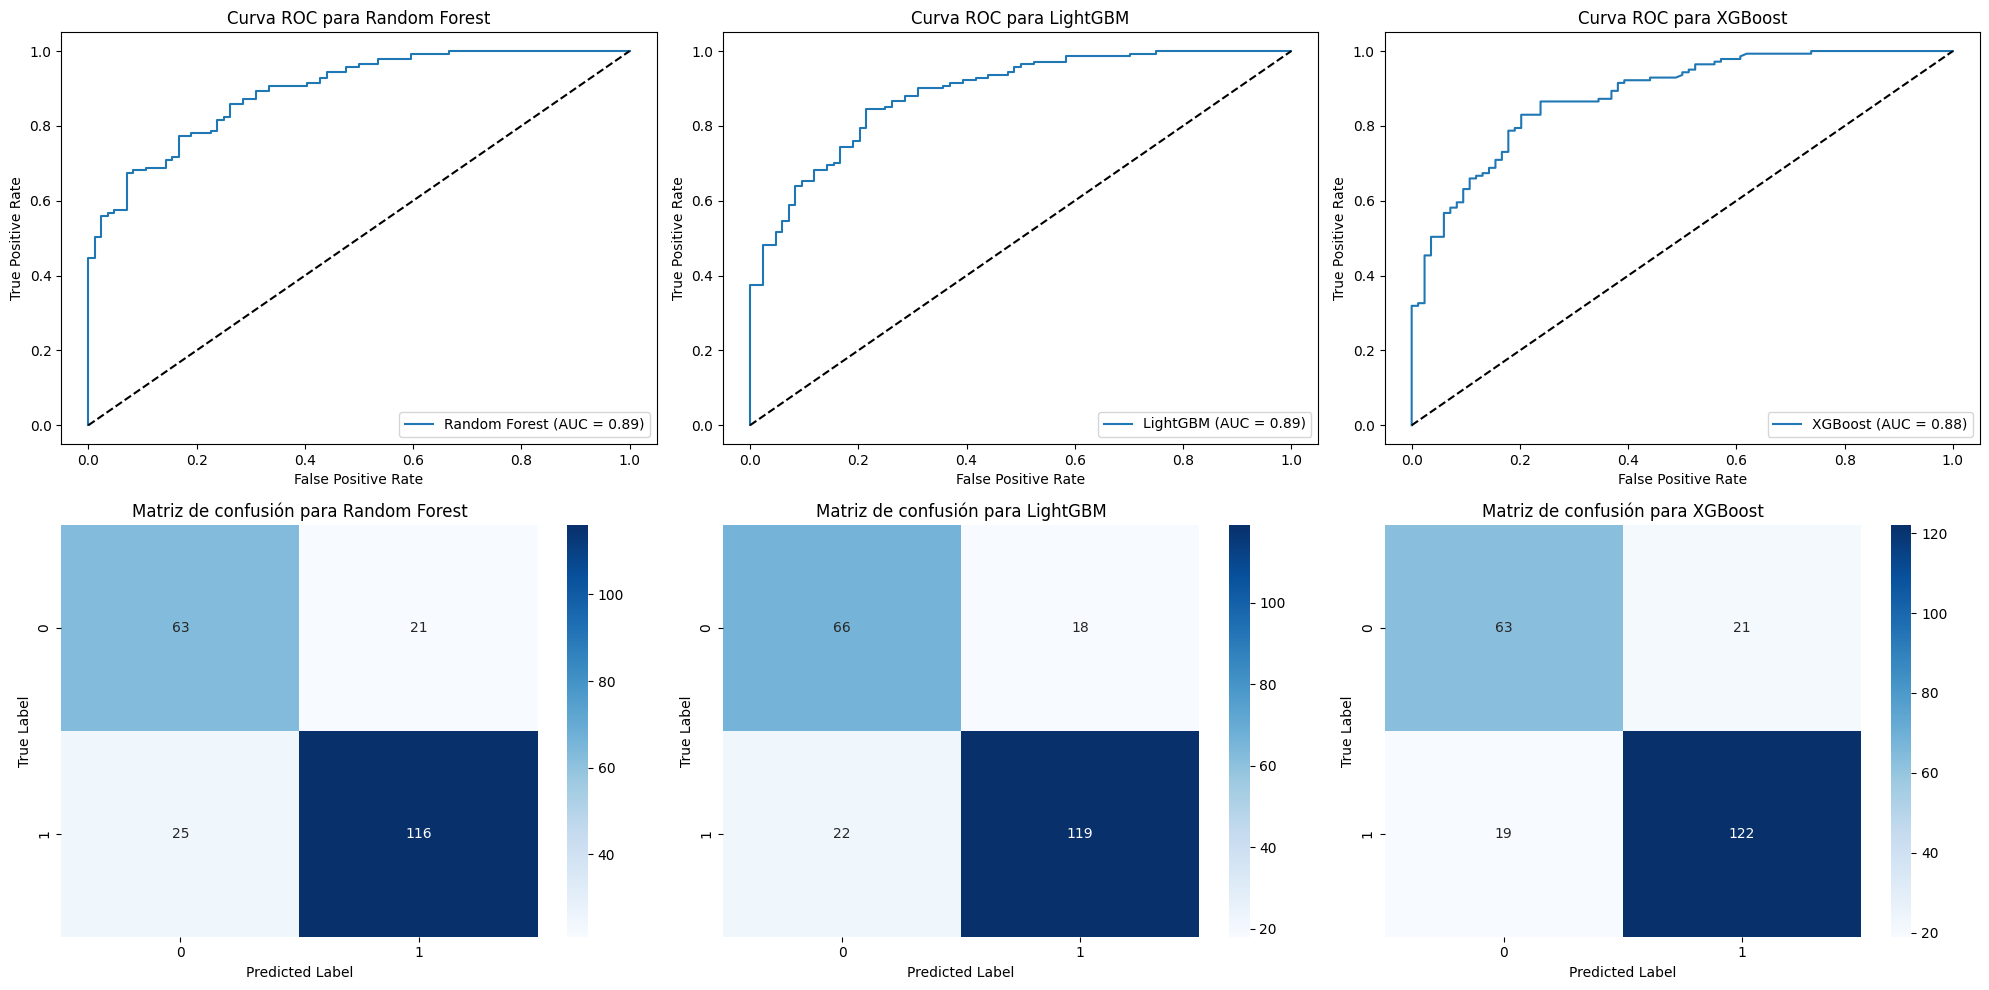

In [ ]:
ensemble_models = [
    ("Random Forest", RandomForestClassifier(**best_params_random_forest), X_train, y_train),
    ("LightGBM", LGBMClassifier(**best_params_lgbm, verbose=-1), X_train, y_train), # verbose = -1
    ("XGBoost", XGBClassifier(**best_params_xgb), X_train, y_train),
]
# Configuración para los subplots
fig, axes = plt.subplots(nrows=2, ncols=len(ensemble_models), figsize=(20, 10))

# Iteramos sobre los modelos
for idx, (model_name, model, X_train, y_train) in enumerate(ensemble_models):
    model.fit(X_train, y_train)

    # Predecir probabilidades y etiquetas
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Primer fila: Curva ROC
    axes[0, idx].plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    axes[0, idx].plot([0, 1], [0, 1], 'k--')  # Línea diagonal
    axes[0, idx].set_title(f'Curva ROC para {model_name}')
    axes[0, idx].set_xlabel('False Positive Rate')
    axes[0, idx].set_ylabel('True Positive Rate')
    axes[0, idx].legend(loc='lower right')

    cm = confusion_matrix(y_test, y_pred)

    # Segunda fila: Matriz de confusión
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, idx])
    axes[1, idx].set_title(f'Matriz de confusión para {model_name}')
    axes[1, idx].set_xlabel('Predicted Label')
    axes[1, idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Conclusiones de lo observado en las curvas ROC y matrices de confusión:

El modelo de **Random Forest** tiene un AUC de 0.89, lo que lo convierte en el mejor discriminador entre las clases. En su matriz de confusión, presenta 116 verdaderos positivos y 25 falsos negativos, lo que indica una sensibilidad de 82.3%. Además, con 63 verdaderos negativos y 21 falsos positivos, mantiene una precisión razonable al minimizar los errores positivos, aunque podría ser mejor en comparación con los otros modelos.

El modelo de **LightGBM** también tiene un AUC de 0.89, lo que sugiere una capacidad de discriminación similar a la de Random Forest. Su matriz de confusión muestra 119 verdaderos positivos y 22 falsos negativos, lo que implica una sensibilidad ligeramente superior de 84.4%. Con 66 verdaderos negativos y 18 falsos positivos, este modelo presenta la mejor precisión en términos de clasificación negativa, lo que sugiere que comete menos errores en la predicción de la clase negativa.

El modelo de **XGBoost** tiene un AUC de 0.88, lo que lo coloca levemente por debajo de los otros dos modelos en términos de discriminación. En su matriz de confusión, se observan 122 verdaderos positivos y 19 falsos negativos, lo que le otorga la mayor sensibilidad entre los tres modelos (86.5%). Sin embargo, con 63 verdaderos negativos y 21 falsos positivos, tiene más falsos positivos en comparación con LightGBM.

###Resumen Comparativo:
**Random Forest**: AUC más alto (0.89) y menor número de falsos positivos (21), pero con la sensibilidad más baja (82.3%).

**LightGBM**: AUC igual al de Random Forest (0.89), con mejor equilibrio entre precisión y sensibilidad. Tiene el menor número de falsos positivos (18) y una sensibilidad de 84.4%.

**XGBoost**: AUC ligeramente menor (0.88) pero con la mayor sensibilidad (86.5%). No obstante, presenta más falsos positivos (21) en comparación con LightGBM.

### Conclusión
Para esta tarea de clasificación, tanto Random Forest como LightGBM tienen un excelente desempeño en términos de AUC.
Sin embargo, LightGBM ofrece un mejor equilibrio entre precisión y sensibilidad, por lo que podría ser la opción más recomendada si es necesario minimizar tanto los falsos positivos como los falsos negativos.
Si la sensibilidad es prioritaria (es decir, si es más importante detectar todos los casos positivos), XGBoost sería la mejor opción. En cambio, si se busca un balance general con menos falsos positivos, Random Forest es una opción sólida.

### Mejores párametros encontrados para cada modelo

In [ ]:
def print_best_params(model_name, params):
    print(f"Best hyperparameters for {model_name}:")
    print("-" * (30 + len(model_name)))
    for param, value in params.items():
        print(f"{param}: {value}")
    print("\n")

In [ ]:
print_best_params("Logistic Regression", best_params_logistic)
print_best_params("KNN", best_params_knn)
print_best_params("Decision Tree", best_params_decision_tree)
print_best_params("LightGBM", best_params_lgbm)
print_best_params("XGBoost", best_params_xgb)
print_best_params("Random Forest", best_params_random_forest)

Best hyperparameters for Logistic Regression:
-------------------------------------------------
C: 0.061584185572212125
penalty: l2
solver: liblinear


Best hyperparameters for KNN:
---------------------------------
n_neighbors: 4
weights: distance
algorithm: auto


Best hyperparameters for Decision Tree:
-------------------------------------------
max_depth: 4
criterion: gini
min_samples_split: 8
min_samples_leaf: 1


Best hyperparameters for LightGBM:
--------------------------------------
n_estimators: 158
learning_rate: 0.05599524409901728
max_depth: 3
num_leaves: 70
min_child_samples: 12
subsample: 0.9706671281339528
colsample_bytree: 0.5507633734858353
reg_alpha: 0.3569509778413112
reg_lambda: 0.11716479608946737


Best hyperparameters for XGBoost:
-------------------------------------
max_depth: 10
learning_rate: 0.01602376884750589
n_estimators: 92
min_child_weight: 7
gamma: 0.538214145595554
subsample: 0.9256254974109048
colsample_bytree: 0.7116031026279334
reg_alpha: 0.886295

### Gráfico metricas métricas entre modelos

In [ ]:
all_models = [("Logistic Regression", LogisticRegression(**best_params_logistic), X_train, y_train),
              ("KNN", KNeighborsClassifier(**best_params_knn), X_train, y_train),
              ("Decision Tree", DecisionTreeClassifier(**best_params_decision_tree), X_train, y_train),
              ("LightGBM", LGBMClassifier(**best_params_lgbm, verbose=-1), X_train, y_train),
              ("XGBoost", XGBClassifier(**best_params_xgb), X_train, y_train),
              ("Random Forest", RandomForestClassifier(**best_params_random_forest), X_train, y_train)
              ]

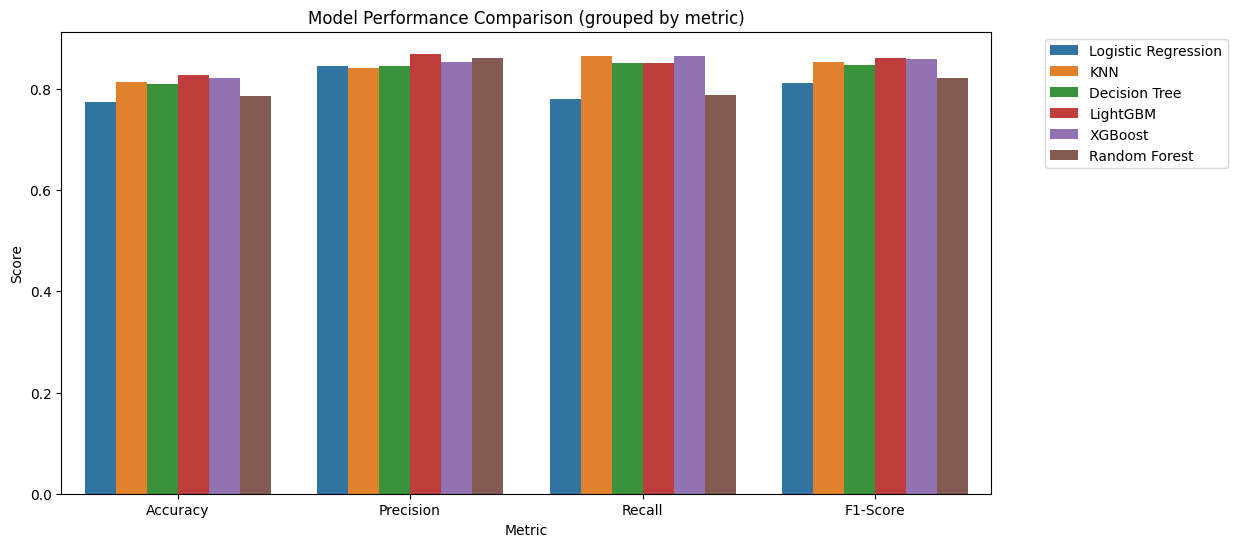

In [ ]:
def get_metrics_for_models(all_models, X_test, y_test):
  model_metrics = {}
  for model_name, model, _, _ in all_models:
      model.fit(X_train, y_train)
      y_pred = model.predict(X_test)

      accuracy = accuracy_score(y_test, y_pred)
      precision = precision_score(y_test, y_pred)
      recall = recall_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred)

      model_metrics[model_name] = {
          'Accuracy': accuracy,
          'Precision': precision,
          'Recall': recall,
          'F1-Score': f1
      }
  return model_metrics


def plot_metrics_by_model(model_metrics):
    metrics_df = pd.DataFrame(model_metrics).T
    metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

    melted_df = pd.melt(metrics_df, id_vars=['Model'], var_name='Metric', value_name='Score')

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Metric', y='Score', hue='Model', data=melted_df)
    plt.title('Model Performance Comparison (grouped by metric)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

model_metrics = get_metrics_for_models(all_models, X_test, y_test)
plot_metrics_by_model(model_metrics)


### Tabla comparativa de métricas entre modelos

In [ ]:
df_results = pd.DataFrame(model_metrics).T

display(df_results.style.highlight_max(axis=0, color='green'))

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.773333,0.846154,0.780142,0.811808
KNN,0.813333,0.841379,0.865248,0.853147
Decision Tree,0.808889,0.845070,0.851064,0.848057
LightGBM,0.826667,0.869565,0.851064,0.860215
XGBoost,0.822222,0.853147,0.865248,0.859155
Random Forest,0.786667,0.860465,0.787234,0.822222


### **Resúmen - Conclusiones**
Comenzamos eligiendo el dataset y estudiando el significado de sus variables, identificando aquella que sería nuestro target para predecir / clasificar.

Estudiamos la distribución de las distintas variables y tratamos de establecer la relación entre ellas y nuestro target.

Aplicamos técnicas de identificación y tratamiento de outliers para mejorar la calidad del dataset y, por lo tanto, el desempeño de los modelos que posteriormente entrenaríamos.

Utilizamos técnicas de reducción de la dimensionalidad para mejorar la performance de los modelos y evitar los problemas de usar todo el dataset. Entrenamos modelos con el dataset completo y con datasets redimensionados utilizando PCA y LDA, comparando la performance entre las distintas variantes.

Utilizamos t-SNE para reducir dimensionalidad y visualizar agrupaciones de datos, con el fin de encontrar patrones o ver relaciones, aunque para este dataset en particular no nos resultó de gran utilidad.

Al inicio del entrenamiento de los modelos, optamos por los más simples como Logistic Regression, Decision Tree y KNN. Luego, continuamos con modelos de Ensemble Learning para ver si aumentaban
las métricas.

Enfocándonos en la métrica `accuracy`, podemos observar que los modelos de ensemble como LightGBM y XGBoost con un valor de (82.22%) para ambos tienen una accuracy ligeramente mayor en comparación con los modelos más simples, como Logistic Regression (77.78%) o Decision Tree (80.89%) lo cual era esperable ya que estos últimos ofrecen una mejor capacidad predictiva.

Si la prioridad es maximizar el rendimiento, los modelos de ensemble son una mejor elección, ya que ofrecen una mayor precisión y un balance óptimo entre precisión y recall. Sin embargo, si se requiere un modelo más simple y fácil de interpretar que requiera menos mantenimiento, los modelos simples podrían ser más adecuados, aunque con una ligera disminución en el rendimiento.
